# FMST_Concrete Compressive Strength Predictor - Regression Model

In [988]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as px
sns.set(style="darkgrid")
sns.set(color_codes=True)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [989]:
#To display comments/observations in 'orange' color and bold
def b(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Observations:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")
def c(text):
    print("\033[1m\x1b[33m",text,"\x1b[0m")
def f(text):
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m","Final Comments:", "\x1b[0m")
    print("\x1b[33m","***********************************************************************************************************************","\x1b[0m")
    print("\033[1m\x1b[33m",text,"\x1b[0m")

In [990]:
df_org = pd.read_csv('concrete.csv')

In [991]:
df_org.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


In [992]:
df_org.tail()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
1025,135.0,0.0,166.0,180.0,10.0,961.0,805.0,28,13.29
1026,531.3,0.0,0.0,141.8,28.2,852.1,893.7,3,41.30
1027,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1028,342.0,38.0,0.0,228.0,0.0,932.0,670.0,270,55.06
1029,540.0,0.0,0.0,173.0,0.0,1125.0,613.0,7,52.61


In [993]:
df_org.shape

(1030, 9)

# 1. Deliverable -1 (Exploratory data quality report reflecting the following)

### a. Univariate analysis

In [994]:
df_org.columns

Index(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'],
      dtype='object')

In [995]:
b("==> Totally, there are 9 features among which 8 features such as {0} are independent variables and 1 feature is dependent variable i.e. {1}".format(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age'], ['strength']))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Totally, there are 9 features among which 8 features such as ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age'] are independent variables and 1 feature is dependent variable i.e. ['strength'] 


In [996]:
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
cement          1030 non-null float64
slag            1030 non-null float64
ash             1030 non-null float64
water           1030 non-null float64
superplastic    1030 non-null float64
coarseagg       1030 non-null float64
fineagg         1030 non-null float64
age             1030 non-null int64
strength        1030 non-null float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [997]:
df_org.dtypes

cement          float64
slag            float64
ash             float64
water           float64
superplastic    float64
coarseagg       float64
fineagg         float64
age               int64
strength        float64
dtype: object

In [998]:
b("==> All features are of numerical types\n\n==> All features are 'contineous' variables as they are represented in some measures*units.\n\n==> {0} are measured in 'kilogram'\n\n==> {1} is measured in 'days'.\n\n==> {2} is measured in 'MPa'".format(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg'],['age'],['strength']))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> All features are of numerical types

==> All features are 'contineous' variables as they are represented in some measures*units.

==> ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg'] are measured in 'kilogram'

==> ['age'] is measured in 'days'.

==> ['strength'] is measured in 'MPa' 


In [999]:
df_org.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
superplastic,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
coarseagg,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
fineagg,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


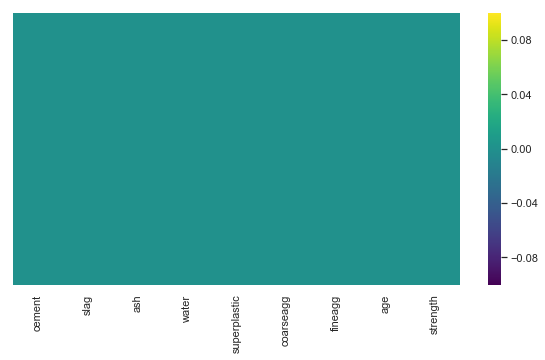

In [1000]:
# NaN or missing value analysis
plt.figure(figsize=(10,5))
sns.heatmap(df_org.isnull(), yticklabels=False, cbar=True, cmap='viridis');

In [1001]:
print("Does dataframe contain any null values? ",df_org.isnull().values.any()) # dataframe contains only 'false' which means there are no null values.
total_nan = df_org.isnull().sum().sum()
if total_nan > 0:
    b("==> There are NaN values present in the original dataset. Null count is", total_nan)
else:
    b("==> There are no NaN values present in the original dataset")

Does dataframe contain any null values?  False
 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are no NaN values present in the original dataset 


In [1002]:
#loading orginal dataframe into new dataframe to add additional columns for summarization
df_summary = df_org.describe().transpose()
#range = max-min
#interquartile range = (q3-q1); whiskers(upper/lower) = (q3-q1)*1.5
#Additional summary
df_summary_fin = pd.concat([df_summary, pd.DataFrame(df_summary['max']-df_summary['min'],columns=['range']),pd.DataFrame(df_summary['75%']-df_summary['25%'],columns=['IQR'])], axis=1)
df_summary_fin

,count,mean,std,min,25%,50%,75%,max,range,IQR
cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0,438.00,157.625
slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4,359.40,142.950
ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1,200.10,118.300
water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0,125.20,27.100
superplastic,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2,32.20,10.200
coarseagg,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0,344.00,97.400
fineagg,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6,398.60,93.050
age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0,364.00,49.000
strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6,80.27,22.425


In [1003]:
#5 point summary table
df_5n_summary = df_summary.rename(columns={'25%':'25%(Q1)', '50%':'50%(Median)','75%':'75%(Q3)'})
print("*****Five point summary *****","\n", df_5n_summary.iloc[:,3:]) 

*****Five point summary ***** 
                  min  25%(Q1)  50%(Median)   75%(Q3)     max
cement        102.00  192.375      272.900   350.000   540.0
slag            0.00    0.000       22.000   142.950   359.4
ash             0.00    0.000        0.000   118.300   200.1
water         121.80  164.900      185.000   192.000   247.0
superplastic    0.00    0.000        6.400    10.200    32.2
coarseagg     801.00  932.000      968.000  1029.400  1145.0
fineagg       594.00  730.950      779.500   824.000   992.6
age             1.00    7.000       28.000    56.000   365.0
strength        2.33   23.710       34.445    46.135    82.6


In [1004]:
b("==> There are no missing values in any of the features however, there are 'zeros' in few columns such as 'slag','ash','superplastic'. That could potentially be the nature of the attribute. So, I'm keeping them as is.\n\n==> Features are in different scales such as kg, age. Scale of 'coarseagg' and 'fineagg' are higher compared to other features that of the same measures. Thus, all independent features need to be normalized to be compressed in a single scale.\n\n==> By looking at the above summary table, 'min'/'max' value is far away from 'mean' value for some of the columns such as 'slag', 'ash','water, 'superplastic', 'age'. There are possible outliers in these columns.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> There are no missing values in any of the features however, there are 'zeros' in few columns such as 'slag','ash','superplastic'. That could potentially be the nature of the attribute. So, I'm keeping them as is.

==> Features are in different scales such as kg, age. Scale of 'coarseagg' and 'fineagg' are higher compared to other features that of the same measures. Thus, all independent features need to be normalized to be compressed in a single scale.

==> By looking at the above summary table, 'min'/'max' value is far away from 'mean' value for some of the columns such as 'slag', 'ash','water, 'superplastic', 'age'. There are possible outliers in these columns. 


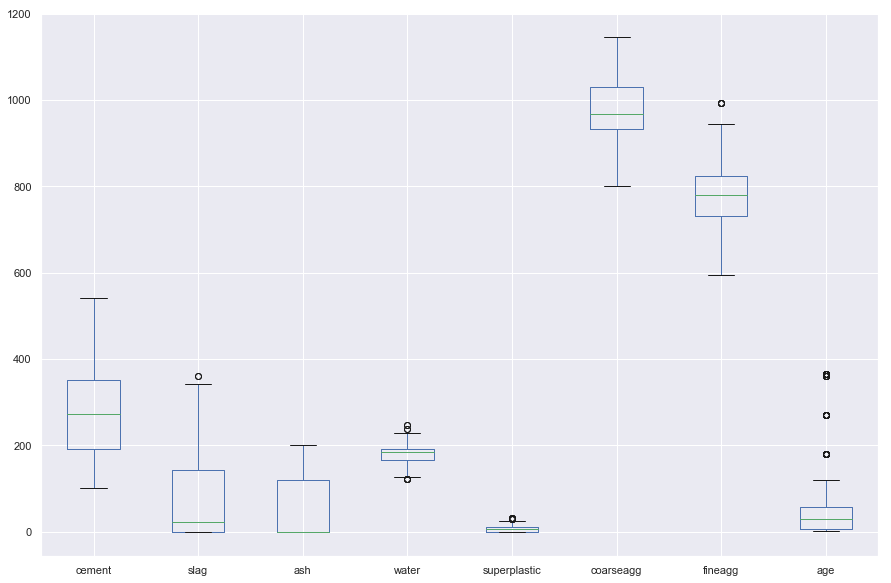

In [1005]:
#Finding outliers & handling them
plt.figure(figsize=(15,10))
df_org.boxplot(column=['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age'])

Data distribution for column 'cement'


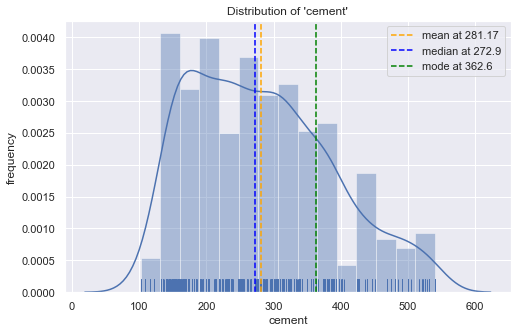

In [1006]:
#data distribution analysis for each attribute
plt.figure(figsize=(8,5))
feature_name = 'cement'
print("Data distribution for column '{0}'".format(feature_name))
sns.distplot(df_org[feature_name],hist=True, kde=True, rug=True);
plt.xlabel(feature_name)
plt.ylabel("frequency")
plt.title(f"Distribution of '"+feature_name+"'")
measurements = [round(df_org[feature_name].mean(),2), round(df_org[feature_name].median(),2), round(df_org[feature_name].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

In [1007]:
b("==> '{0}' - Both the sides are approximately symmetric from median point. Also, mean is closer to median. Hence, attribute has a normal/gaussian data distribution in it.".format(feature_name))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> 'cement' - Both the sides are approximately symmetric from median point. Also, mean is closer to median. Hence, attribute has a normal/gaussian data distribution in it. 


Data distribution for column 'slag'


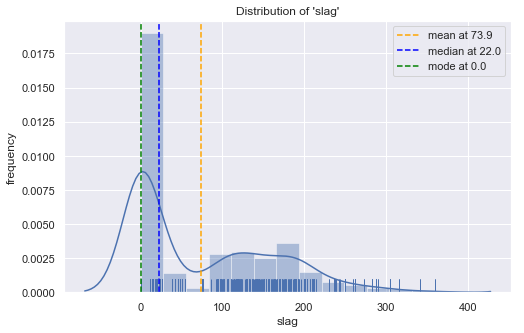

In [1008]:
#data distribution analysis for each attribute
plt.figure(figsize=(8,5))
feature_name = 'slag'
print("Data distribution for column '{0}'".format(feature_name))
sns.distplot(df_org[feature_name],hist=True, kde=True, rug=True);
plt.xlabel(feature_name)
plt.ylabel("frequency")
plt.title(f"Distribution of '"+feature_name+"'")
measurements = [round(df_org[feature_name].mean(),2), round(df_org[feature_name].median(),2), round(df_org[feature_name].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

In [1009]:
b("==> '{0}' - It seems distribution dense is much higher in 0-25 value range. And, right side tail is far away from the central values. Hence, attribute can be considered as approximately positively/right skewed data distribution.".format(feature_name))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> 'slag' - It seems distribution dense is much higher in 0-25 value range. And, right side tail is far away from the central values. Hence, attribute can be considered as approximately positively/right skewed data distribution. 


Data distribution for column 'ash'


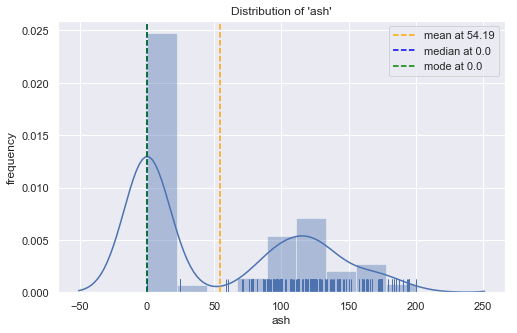

In [1010]:
#data distribution analysis for each attribute
plt.figure(figsize=(8,5))
feature_name = 'ash'
print("Data distribution for column '{0}'".format(feature_name))
sns.distplot(df_org[feature_name],hist=True, kde=True, rug=True);
plt.xlabel(feature_name)
plt.ylabel("frequency")
plt.title(f"Distribution of '"+feature_name+"'")
measurements = [round(df_org[feature_name].mean(),2), round(df_org[feature_name].median(),2), round(df_org[feature_name].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

In [1011]:
b("==> '{0}' - It seems distribution dense is much higher in 0-20 value range. And, right side tail is far away from the central values. Hence, attribute can be considered as approximately positively/right skewed data distribution.".format(feature_name))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> 'ash' - It seems distribution dense is much higher in 0-20 value range. And, right side tail is far away from the central values. Hence, attribute can be considered as approximately positively/right skewed data distribution. 


Data distribution for column 'water'


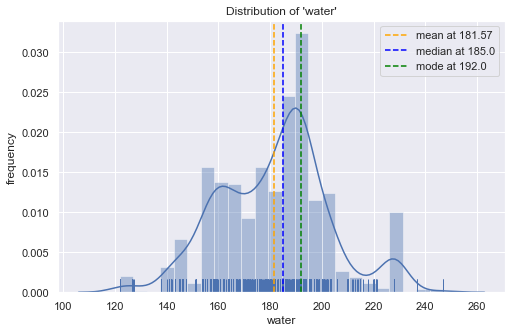

In [1012]:
#data distribution analysis for each attribute
plt.figure(figsize=(8,5))
feature_name = 'water'
print("Data distribution for column '{0}'".format(feature_name))
sns.distplot(df_org[feature_name],hist=True, kde=True, rug=True);
plt.xlabel(feature_name)
plt.ylabel("frequency")
plt.title(f"Distribution of '"+feature_name+"'")
measurements = [round(df_org[feature_name].mean(),2), round(df_org[feature_name].median(),2), round(df_org[feature_name].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

In [1013]:
b("==> '{0}' - Both the sides are approximately symmetric from median point. Also, mean is closer to median. Hence, attribute can be considered as approximately normal/gaussian data distribution.".format(feature_name))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> 'water' - Both the sides are approximately symmetric from median point. Also, mean is closer to median. Hence, attribute can be considered as approximately normal/gaussian data distribution. 


Data distribution for column 'superplastic'


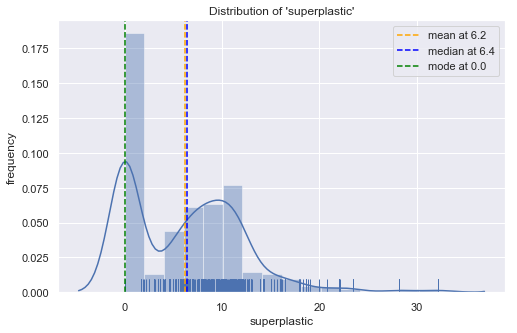

In [1014]:
#data distribution analysis for each attribute
plt.figure(figsize=(8,5))
feature_name = 'superplastic'
print("Data distribution for column '{0}'".format(feature_name))
sns.distplot(df_org[feature_name],hist=True, kde=True, rug=True);
plt.xlabel(feature_name)
plt.ylabel("frequency")
plt.title(f"Distribution of '"+feature_name+"'")
measurements = [round(df_org[feature_name].mean(),2), round(df_org[feature_name].median(),2), round(df_org[feature_name].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

In [1015]:
b("==> '{0}' - It seems distribution dense is much higher in 0-1 value range. And, right side tail is far away from the central values. Hence, attribute can be considered as approximately positively/right skewed data distribution.".format(feature_name))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> 'superplastic' - It seems distribution dense is much higher in 0-1 value range. And, right side tail is far away from the central values. Hence, attribute can be considered as approximately positively/right skewed data distribution. 


Data distribution for column 'coarseagg'


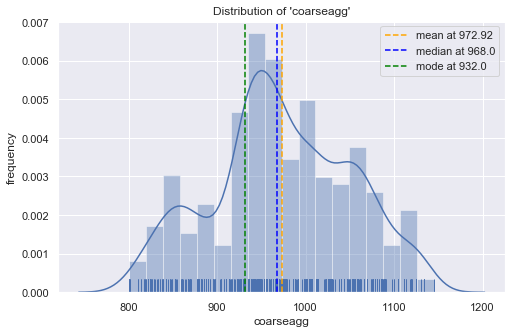

In [1016]:
#data distribution analysis for each attribute
plt.figure(figsize=(8,5))
feature_name = 'coarseagg'
print("Data distribution for column '{0}'".format(feature_name))
sns.distplot(df_org[feature_name],hist=True, kde=True, rug=True);
plt.xlabel(feature_name)
plt.ylabel("frequency")
plt.title(f"Distribution of '"+feature_name+"'")
measurements = [round(df_org[feature_name].mean(),2), round(df_org[feature_name].median(),2), round(df_org[feature_name].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

In [1017]:
b("==> '{0}' - Both the sides are approximately symmetric from median point. Also, mean is closer to median. Hence, attribute can be considered as approximately normal/gaussian data distribution.".format(feature_name))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> 'coarseagg' - Both the sides are approximately symmetric from median point. Also, mean is closer to median. Hence, attribute can be considered as approximately normal/gaussian data distribution. 


Data distribution for column 'fineagg'


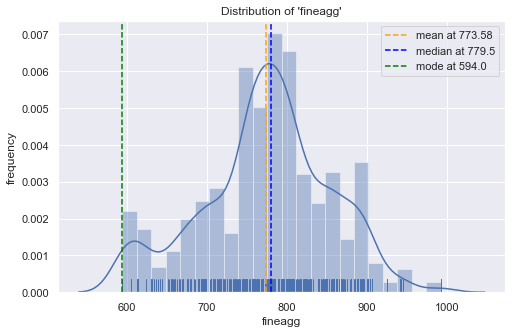

In [1018]:
#data distribution analysis for each attribute
plt.figure(figsize=(8,5))
feature_name = 'fineagg'
print("Data distribution for column '{0}'".format(feature_name))
sns.distplot(df_org[feature_name],hist=True, kde=True, rug=True);
plt.xlabel(feature_name)
plt.ylabel("frequency")
plt.title(f"Distribution of '"+feature_name+"'")
measurements = [round(df_org[feature_name].mean(),2), round(df_org[feature_name].median(),2), round(df_org[feature_name].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

In [1019]:
b("==> '{0}' - Both the sides are approximately symmetric from median point. Also, mean is closer to median. Hence, attribute can be considered as approximately normal/gaussian data distribution.".format(feature_name))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> 'fineagg' - Both the sides are approximately symmetric from median point. Also, mean is closer to median. Hence, attribute can be considered as approximately normal/gaussian data distribution. 


Data distribution for column 'age'


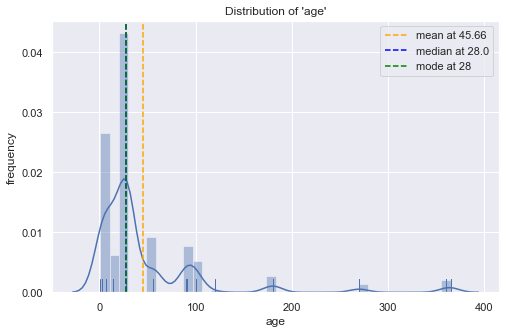

In [1020]:
#data distribution analysis for each attribute
plt.figure(figsize=(8,5))
feature_name = 'age'
print("Data distribution for column '{0}'".format(feature_name))
sns.distplot(df_org[feature_name],hist=True, kde=True, rug=True);
plt.xlabel(feature_name)
plt.ylabel("frequency")
plt.title(f"Distribution of '"+feature_name+"'")
measurements = [round(df_org[feature_name].mean(),2), round(df_org[feature_name].median(),2), round(df_org[feature_name].mode()[0],2)]
names = ["mean", "median", "mode"]
colors = ['orange', 'blue', 'green']
for measurement, name, color in zip(measurements, names, colors):
    plt.axvline(x=measurement, linestyle='--', color=color, label='{0} at {1}'.format(name, measurement))
plt.legend();

In [1021]:
b("==> '{0}' - It seems right side tail is long and far away from the central values. Hence, attribute can be considered as approximately positively/right skewed data distribution.".format(feature_name))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> 'age' - It seems right side tail is long and far away from the central values. Hence, attribute can be considered as approximately positively/right skewed data distribution. 


In [1022]:
df_org.skew()

cement          0.509481
slag            0.800717
ash             0.537354
water           0.074628
superplastic    0.907203
coarseagg      -0.040220
fineagg        -0.253010
age             3.269177
strength        0.416977
dtype: float64

In [1023]:
b("==> As we explored from above distribution plotting, the columns such as 'water', 'coarseagg', 'fineagg' are approximately normally distributed as its skewness values is closer to 0.\n\n==> Other columns are right skewed as skewness value goes beyond 0.5.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> As we explored from above distribution plotting, the columns such as 'water', 'coarseagg', 'fineagg' are approximately normally distributed as its skewness values is closer to 0.

==> Other columns are right skewed as skewness value goes beyond 0.5. 


### b. Multivariate analysis

In [1024]:
#Pearson's correlation coefficiency check between two features
df_org.corr()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
cement,1.000000,-0.275216,-0.397467,-0.081587,0.092386,-0.109349,-0.222718,0.081946,0.497832
slag,-0.275216,1.000000,-0.323580,0.107252,0.043270,-0.283999,-0.281603,-0.044246,0.134829
ash,-0.397467,-0.323580,1.000000,-0.256984,0.377503,-0.009961,0.079108,-0.154371,-0.105755
water,-0.081587,0.107252,-0.256984,1.000000,-0.657533,-0.182294,-0.450661,0.277618,-0.289633
superplastic,0.092386,0.043270,0.377503,-0.657533,1.000000,-0.265999,0.222691,-0.192700,0.366079
coarseagg,-0.109349,-0.283999,-0.009961,-0.182294,-0.265999,1.000000,-0.178481,-0.003016,-0.164935
fineagg,-0.222718,-0.281603,0.079108,-0.450661,0.222691,-0.178481,1.000000,-0.156095,-0.167241
age,0.081946,-0.044246,-0.154371,0.277618,-0.192700,-0.003016,-0.156095,1.000000,0.328873
strength,0.497832,0.134829,-0.105755,-0.289633,0.366079,-0.164935,-0.167241,0.328873,1.000000


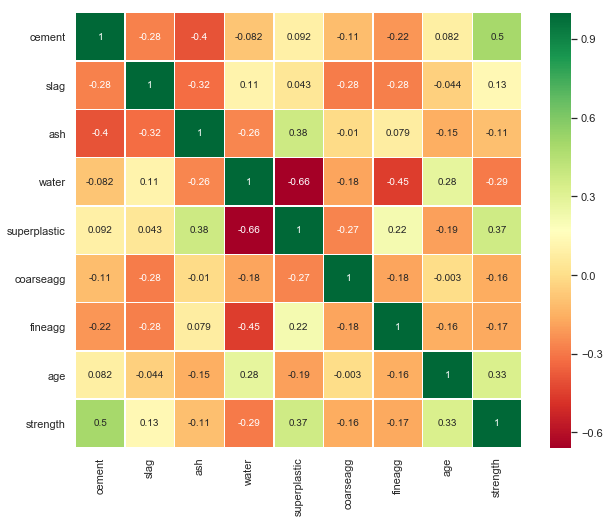

In [1025]:
#headmap of correlation between two features
plt.figure(figsize=(10,8))
sns.heatmap(df_org.corr(), annot=True, linewidth=0.5, cmap='RdYlGn')

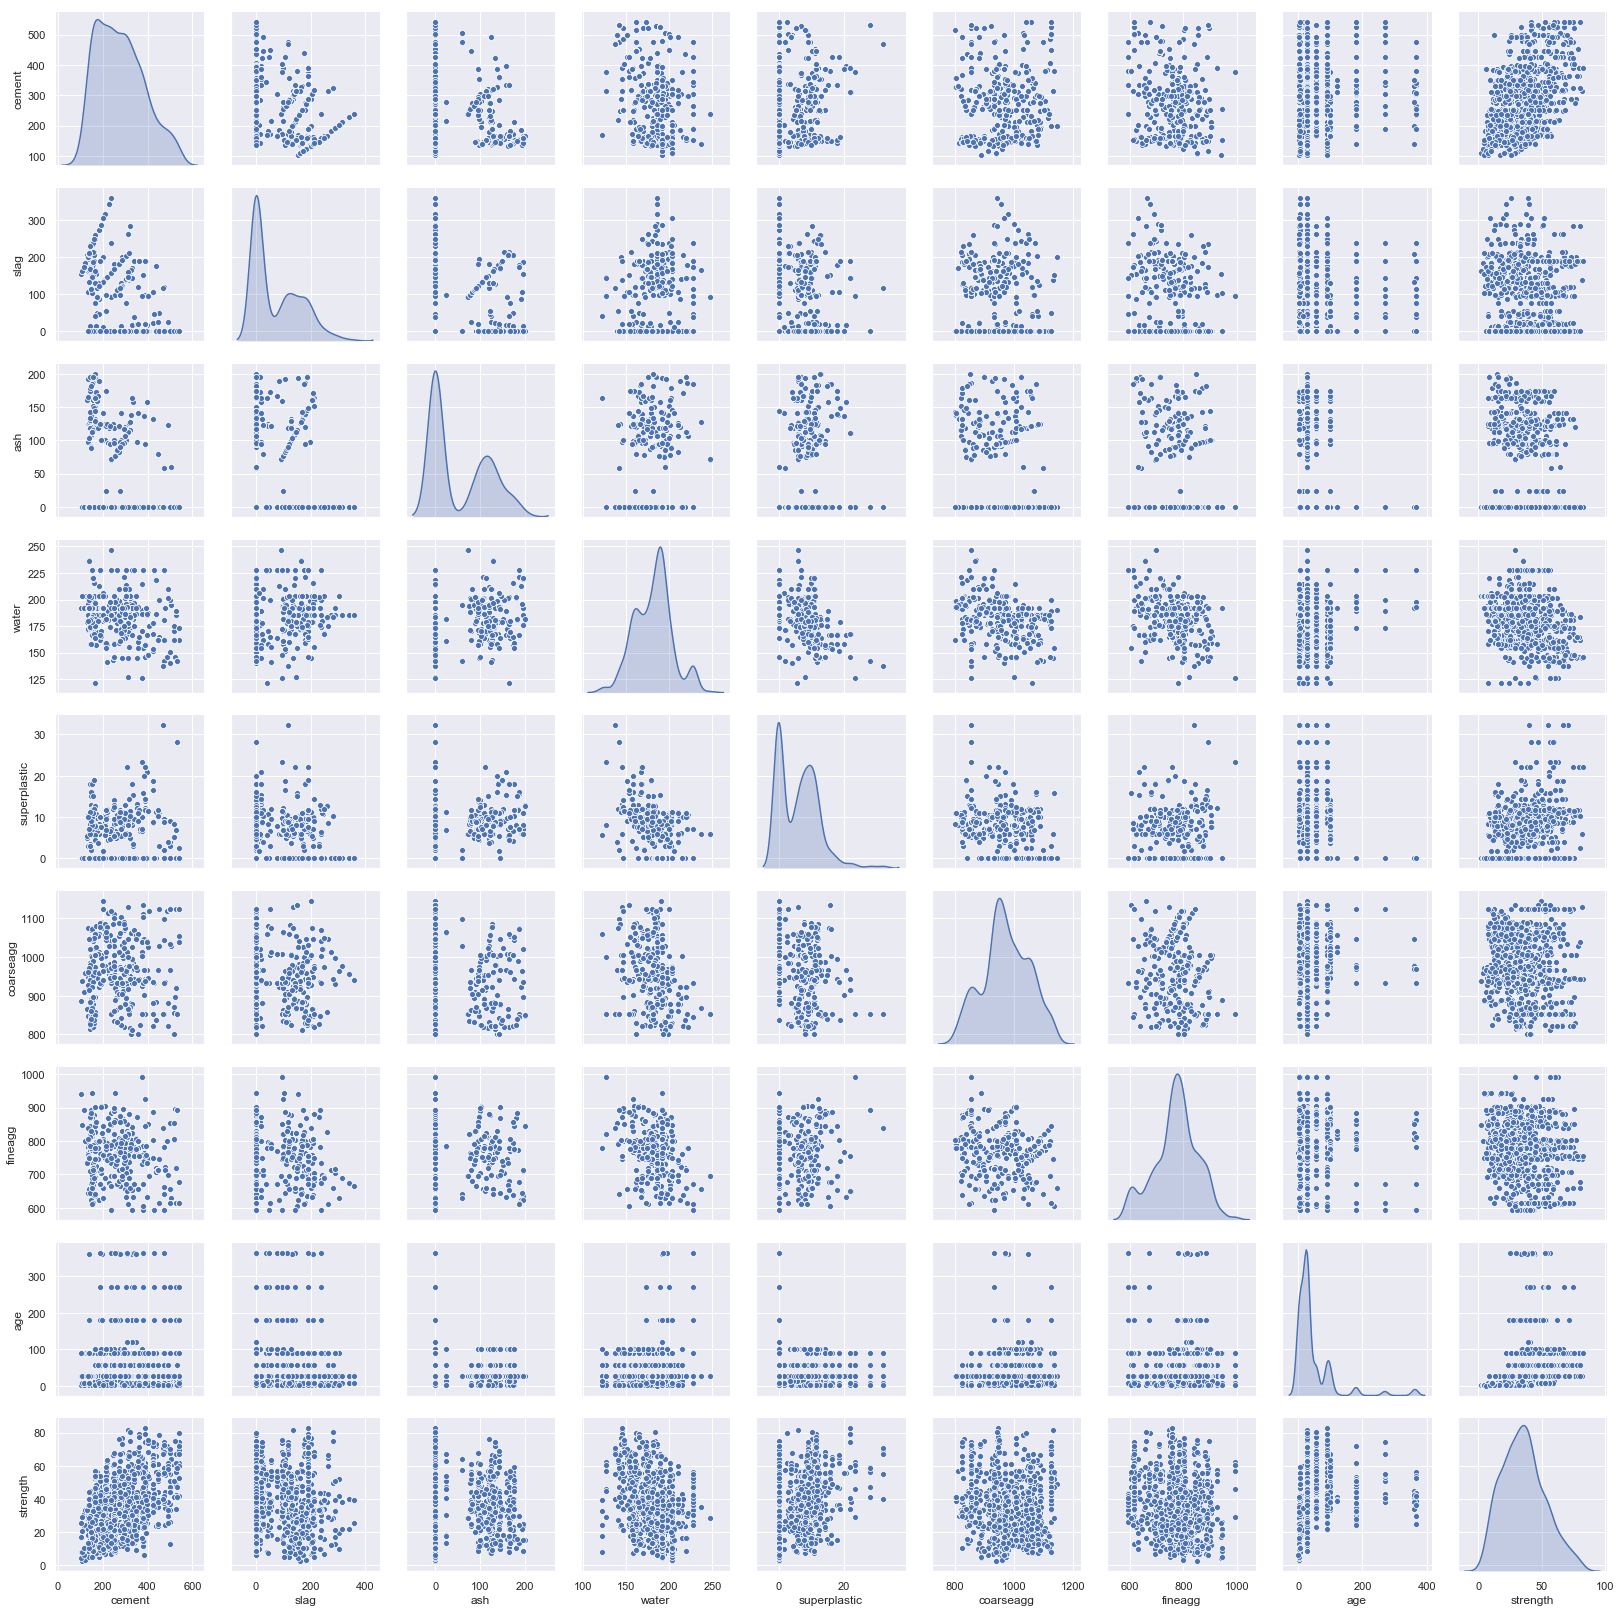

In [1026]:
#distribution and pairplot of same feature and between two features.
sns.pairplot(df_org, diag_kind='kde');

In [1027]:
b("==> From the above heatmap and pair plotting, it seems that independent columns 'water' and superplastic' are negatively correlated as its 'r' value goes beyond 0.5. For now, I'm keeping the these columns as is without eliminating.\n\n==> Predictors such as 'cement', 'superplastic','age' are having better linear relationship with dependent variable 'strength' than other predictors.\n\n==> Also, by looking at the above plot, it's evident that independent variables are not much linearly correlated with dependent variable 'strength'. Hence, polinomial/quadradic models might perform well over linera models.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> From the above heatmap and pair plotting, it seems that independent columns 'water' and superplastic' are negatively correlated as its 'r' value goes beyond 0.5. For now, I'm keeping the these columns as is without eliminating.

==> Predictors such as 'cement', 'superplastic','age' are having better linear relationship with dependent variable 'strength' than other predictors.

==> Also, by looking at the above plot, it's evident that independent variables are not much linearly correlated with dependent variable 'strength'. Hence, polinomial/quadradic models might perform well over linera models. 


In [1028]:
#Picking up few linearly correlating features such as 'cement', 'age' with target variable 'strength' 
# and checking it's linearity and non-linearity

In [1036]:
#Linear fit check

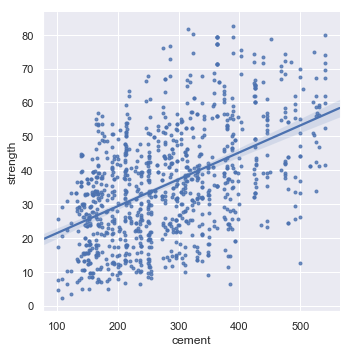

In [1030]:
sns.lmplot(y="strength", x="cement", data=df_org, markers='.');

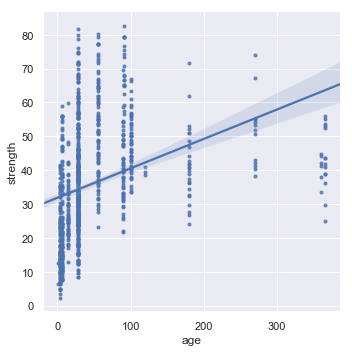

In [1031]:
sns.lmplot(y="strength", x="age", data=df_org, markers='.');

In [1037]:
#Polynomial fit check

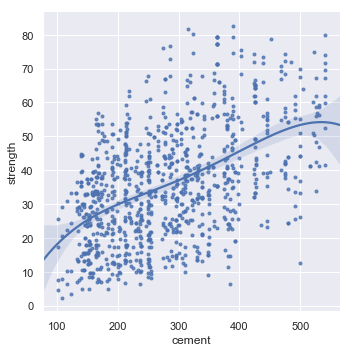

In [1038]:
sns.lmplot(y="strength", x="cement", data=df_org, markers='.', order=4);

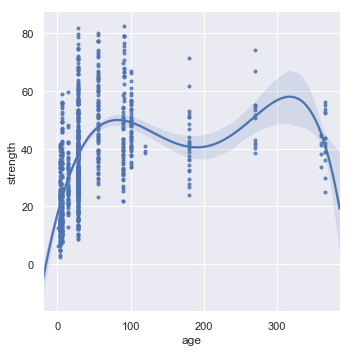

In [1039]:
sns.lmplot(y="strength", x="age", data=df_org, markers='.', order=5);

In [1040]:
b("==> From the above plotting, it seems that polinomial fit w/ higher order '4' fits avergely well")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> From the above plotting, it seems that polinomial fit w/ higher order '4' fits avergely well 


### c. Pick one strategy to address the presence outliers and missing values and perform necessary imputation

In [1041]:
#Handling outliers

In [1042]:
#To get IQR for given column
def iqr(col_name):
    oneandhalf_iqr = (df_summary_fin.loc[col_name]['IQR'])*1.5
    outlier_lb = (df_summary_fin.loc[col_name]['25%'])-oneandhalf_iqr
    outlier_ub = (df_summary_fin.loc[col_name]['75%'])+oneandhalf_iqr
    return oneandhalf_iqr,outlier_lb,outlier_ub

#to get upper & lower outliers count, and its total count for given column
def outliers_cnt(col_name):
    lower_outliers = len(df_org[df_org[col_name]<iqr(col_name)[1]])
    upper_outliers = len(df_org[df_org[col_name]>iqr(col_name)[2]])
    total_outliers = len(df_org[df_org[col_name]<iqr(col_name)[1]])+len(df_org[df_org[col_name]>iqr(col_name)[2]])
    return lower_outliers, upper_outliers, total_outliers

In [1043]:
b("")
for feature_name in list(df_org.columns)[0:-1]:
    outliers_dict = {"lower_outliers":outliers_cnt(feature_name)[0], "upper_outliers":outliers_cnt(feature_name)[1],"total_outliers":outliers_cnt(feature_name)[2]}
    c("==> Outlier details for column '"+feature_name+"' is "+str(outliers_dict))

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
  
 ==> Outlier details for column 'cement' is {'lower_outliers': 0, 'upper_outliers': 0, 'total_outliers': 0} 
 ==> Outlier details for column 'slag' is {'lower_outliers': 0, 'upper_outliers': 2, 'total_outliers': 2} 
 ==> Outlier details for column 'ash' is {'lower_outliers': 0, 'upper_outliers': 0, 'total_outliers': 0} 
 ==> Outlier details for column 'water' is {'lower_outliers': 5, 'upper_outliers': 4, 'total_outliers': 9} 
 ==> Outlier details for column 'superplastic' is {'lower_outliers': 0, 'upper_outliers': 10, 'total_outliers': 10} 
 ==> Outlier details for column 'coarseagg' is {'lower_outliers': 0, 'upper_outliers': 0, 'total_outliers': 0} 
 ==> Outlier details for column 'fineagg' is {'lower_outliers': 0, 'upper_outl

In [1044]:
# Handling Outliers - replacing outlier values with median value  
# for feature_name in list(df_org.columns)[0:-1]:
#     median_val = df_org[feature_name].median()
#     outlier_lb = iqr(feature_name)[1]
#     outlier_ub = iqr(feature_name)[2]
#     df_org[feature_name] = np.where(df_org[feature_name] < outlier_lb, median_val, df_org[feature_name])
#     df_org[feature_name] = np.where(df_org[feature_name] > outlier_ub, median_val, df_org[feature_name])


#NOTE: replacing w/ median value didn't yield convincing results. Hencing replacing w/ upper or lower boundary value.

In [1045]:
#Handling Outliers - replacing outlier values with its upper/lower boundary value
for feature_name in list(df_org.columns)[0:-1]:
    median_val = df_org[feature_name].median()
    outlier_lb = iqr(feature_name)[1]
    outlier_ub = iqr(feature_name)[2]
    df_org[feature_name] = np.where(df_org[feature_name] < outlier_lb, outlier_lb, df_org[feature_name])
    df_org[feature_name] = np.where(df_org[feature_name] > outlier_ub, outlier_ub, df_org[feature_name])

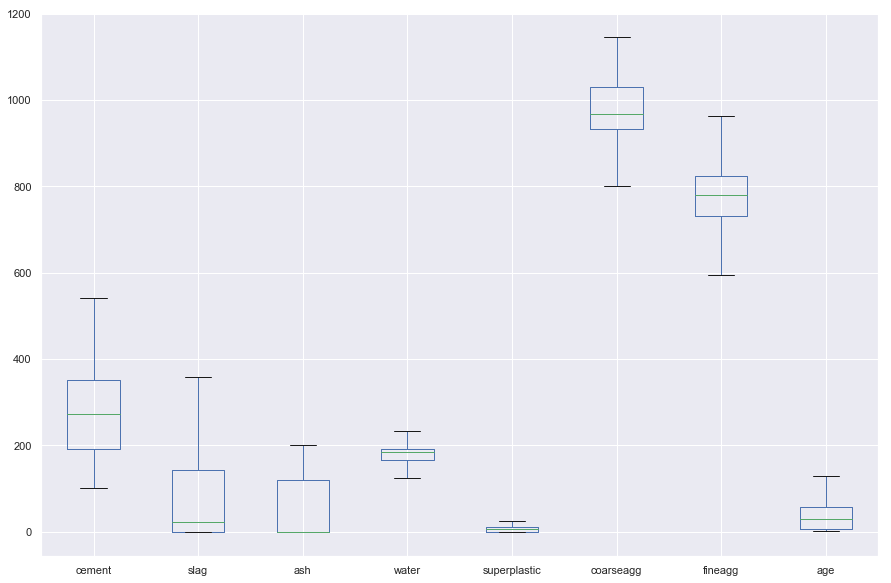

In [1046]:
#Finding outliers & handling them
plt.figure(figsize=(15,10))
df_org.boxplot(column=['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age']);

In [1047]:
b("==> As you can see in the above box plotting, most of the outliers values are now largely reduced by replacing with median value.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> As you can see in the above box plotting, most of the outliers values are now largely reduced by replacing with median value. 


# 2. Deliverable -2 (Feature Engineering techniques)

### a. Identify opportunities (if any) to create a composite feature, drop a feature etc.

### b. Decide on complexity of the model, should it be simple linear model in terms of parameters or would a quadratic or higher degree help

### Approach # 1: 
### Checking model performance on the raw dataset without performing any scaling/feature engineering

In [1048]:
# Copy only predictors. Keeping all 8 features as is.
X = df_org.iloc[:,0:-1]
# Copy only target column
y = df_org.iloc[:,-1:]
print(X.shape)
print(y.shape)

(1030, 8)
(1030, 1)


In [1049]:
#Importing required list of regression alogorithms
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn import svm
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
# from catboost import CatBoostRegressor  -> Unable to import due to some conflicts in the lower lever package 'numpy'. may be version compatibility issue
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor

#Importing required hyper paramter tuning supported packages
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

#Importing required cross validation libraries
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer
# Importing required model evalution functions
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_squared_log_error
import sklearn.metrics as metrics

#Importing time package for tracking model run time
from time import time

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
random_st = 51
stratify_ind = None

In [1050]:
# Defining predictor engines for each algo
ols_lr = LinearRegression()
ridge = Ridge()
lasso = Lasso()
svr = svm.SVR()
dtr = DecisionTreeRegressor()
br = BaggingRegressor()
rf = RandomForestRegressor()
gbr = GradientBoostingRegressor()
xgbr = XGBRegressor()
lgbmr = LGBMRegressor()
knnr = KNeighborsRegressor()
algo_engines = [ols_lr, ridge, lasso, svr, dtr, br, rf, gbr, xgbr, lgbmr, knnr]

In [1051]:
#Didn't apply any scaler technique. Trying on raw data as is.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

In [1052]:
#Regression model evalution metrics
final_model_results = pd.DataFrame()
def regressor_performance_metrics(predictor_name, scaling_type, fe_type, X_train, y_train, X_test, y_test):
    df_models_score = pd.DataFrame(columns = ['Model_Name','Scaling_Tech_Applied','FE_Tech_Applied', 'MAE', 'MSE', 'MSLE', 'RMSE', 'R2', 'Adjusted_R2', 'Model_Run_Duration_in_sec'])
    for algo_eng in predictor_name:
        start_time = time()
        algo_eng.fit(X_train, y_train)
        y_pred = algo_eng.predict(X_test)
        end_time = time()
        model_run_duration = end_time - start_time
        model_score = {'Model_Name':str(algo_eng).split('(')[0], 'Scaling_Tech_Applied':scaling_type, 'FE_Tech_Applied':fe_type, 'MAE':mean_absolute_error(y_test, y_pred), 'MSE':mean_squared_error(y_test, y_pred), 'MSLE': mean_squared_log_error(y_test, y_pred), 'RMSE':np.sqrt(mean_squared_error(y_test, y_pred)), 'R2':r2_score(y_test, y_pred), 'Adjusted_R2':(1 - (1-algo_eng.score(X_test, y_test))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)), 'Model_Run_Duration_in_sec':model_run_duration}
        df_models_score = df_models_score.append(model_score, ignore_index=True)
        #Making use of existing CV scorers
        start_time = time()
        scorer = {'MAE':metrics.make_scorer(metrics.mean_absolute_error), 'MSE':metrics.make_scorer(metrics.mean_squared_error), 'MSLE': metrics.make_scorer(metrics.mean_squared_log_error), 'R2':metrics.make_scorer(metrics.r2_score)}
        cv = cross_validate(algo_eng, X_train, y_train, cv=5, scoring=scorer)
        mae_cv = cv['test_MAE'].mean()
        mse_cv = cv['test_MSE'].mean()
        msle_cv = cv['test_MSLE'].mean()
        r2_cv = cv['test_R2'].mean()
        #Unable to get Adjusted R2 value for Cross Validation
        end_time = time()
        model_run_duration = end_time - start_time  
        model_cv_score = {'Model_Name':str(algo_eng).split('(')[0]+"_CV", 'Scaling_Tech_Applied':scaling_type, 'FE_Tech_Applied':fe_type, 'MAE': mae_cv, 'MSE': mse_cv, 'MSLE': msle_cv,'RMSE':np.sqrt(mse_cv), 'R2':r2_cv, 'Adjusted_R2':None, 'Model_Run_Duration_in_sec':model_run_duration}
        df_models_score = df_models_score.append(model_cv_score, ignore_index=True)   
        df_models_score = df_models_score.sort_values(by=['R2','Adjusted_R2'], ascending=False)
    return df_models_score

In [1053]:
model_results = regressor_performance_metrics(algo_engines, "No Scaler", "No FE. Used all 8 features", X_train, y_train, X_test, y_test)
final_model_results = final_model_results.append(model_results.head(2), ignore_index=True)
model_results

,Model_Name,Scaling_Tech_Applied,FE_Tech_Applied,MAE,MSE,MSLE,RMSE,R2,Adjusted_R2,Model_Run_Duration_in_sec
0,XGBRegressor,No Scaler,No FE. Used all 8 features,2.518013,14.556527,0.018671,3.815302,0.939091,0.937466,0.107714
1,LGBMRegressor,No Scaler,No FE. Used all 8 features,2.733912,15.696037,0.020857,3.961822,0.934323,0.932571,0.079787
2,LGBMRegressor_CV,No Scaler,No FE. Used all 8 features,3.476118,25.220321,0.023170,5.021984,0.913060,None,0.398934
3,RandomForestRegressor,No Scaler,No FE. Used all 8 features,3.267540,21.378948,0.026941,4.623737,0.910543,0.908158,0.274266
4,XGBRegressor_CV,No Scaler,No FE. Used all 8 features,3.505406,28.423291,0.026703,5.331350,0.902344,None,0.455780
5,GradientBoostingRegressor,No Scaler,No FE. Used all 8 features,3.625005,23.581366,0.027349,4.856065,0.901328,0.898696,0.105717
6,GradientBoostingRegressor_CV,No Scaler,No FE. Used all 8 features,4.009947,30.260509,0.027329,5.500955,0.895850,None,0.548534
7,RandomForestRegressor_CV,No Scaler,No FE. Used all 8 features,3.924541,31.116560,0.029761,5.578222,0.892873,None,1.216783
8,BaggingRegressor,No Scaler,No FE. Used all 8 features,3.692418,26.765521,0.032388,5.173540,0.888004,0.885018,0.033910
9,BaggingRegressor_CV,No Scaler,No FE. Used all 8 features,4.237165,35.580448,0.033206,5.964935,0.876756,None,0.165555


### Approach # 2: 
### Checking model performance on the raw dataset after scaling but without performing any feature engineering

In [1054]:
# Copy only predictors. Keeping all 8 features as is.
X = df_org.iloc[:,0:-1]
# Copy only target column
y = df_org.iloc[:,-1:]
print(X.shape)
print(y.shape)

(1030, 8)
(1030, 1)


In [1055]:
#Using best scaler after comparing with other scalers

scaler = preprocessing.MaxAbsScaler()
# scaler = preprocessing.RobustScaler() --> I applied this scaler and confirmed it didn't yield good results comparitively
# scaler = preprocessing.MinMaxScaler() --> I applied this scaler and confirmed it didn't yield good results comparitively
# scaler = preprocessing.StandardScaler() --> I applied this scaler and confirmed it didn't yield good results comparitively
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)
# Applying Scaling technique on the train/train data individually to avoid data leakage
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.fit_transform(X_test), columns=X_test.columns)

In [1056]:
model_results = regressor_performance_metrics(algo_engines, "Max Absolute Scaler", "No FE. Used all 8 features", X_train, y_train, X_test, y_test)
final_model_results = final_model_results.append(model_results.head(2), ignore_index=True)
model_results

,Model_Name,Scaling_Tech_Applied,FE_Tech_Applied,MAE,MSE,MSLE,RMSE,R2,Adjusted_R2,Model_Run_Duration_in_sec
0,XGBRegressor,Max Absolute Scaler,No FE. Used all 8 features,2.992585,18.057825,0.022938,4.249450,0.924440,0.922425,0.074749
1,LGBMRegressor,Max Absolute Scaler,No FE. Used all 8 features,3.168884,19.254935,0.024550,4.388045,0.919431,0.917282,0.082779
2,LGBMRegressor_CV,Max Absolute Scaler,No FE. Used all 8 features,3.476118,25.220321,0.023170,5.021984,0.913060,None,0.411900
3,RandomForestRegressor,Max Absolute Scaler,No FE. Used all 8 features,3.409988,22.431439,0.026967,4.736184,0.906139,0.903636,0.282297
4,XGBRegressor_CV,Max Absolute Scaler,No FE. Used all 8 features,3.507066,28.408243,0.026645,5.329938,0.902391,None,0.421872
5,GradientBoostingRegressor_CV,Max Absolute Scaler,No FE. Used all 8 features,4.010804,30.441118,0.027322,5.517347,0.895117,None,0.472734
6,RandomForestRegressor_CV,Max Absolute Scaler,No FE. Used all 8 features,3.930888,31.137506,0.029252,5.580099,0.892731,None,1.346116
7,BaggingRegressor,Max Absolute Scaler,No FE. Used all 8 features,3.665776,27.119772,0.029279,5.207665,0.886522,0.883496,0.031862
8,GradientBoostingRegressor,Max Absolute Scaler,No FE. Used all 8 features,3.892650,27.801027,0.031352,5.272668,0.883671,0.880569,0.103734
9,BaggingRegressor_CV,Max Absolute Scaler,No FE. Used all 8 features,4.244655,34.585262,0.032207,5.880924,0.880992,None,0.160569


### Approach # 3: 
### Checking model performance on the dataset after dropping feature 'water' manually which is negatively correlated with feature 'superplastic' from scaled dataset as it might lead to multi-collinearity

In [1057]:
X = df_org[['cement', 'slag', 'ash', 'superplastic', 'coarseagg', 'fineagg','age' ]]
y = df_org['strength']
print(X.shape)
print(y.shape)

(1030, 7)
(1030,)


In [1058]:
#Using best scaler after comparing with other scalers
scaler = preprocessing.MaxAbsScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)
# Applying Scaling technique on the train/train data individually to avoid data leakage
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.fit_transform(X_test), columns=X_test.columns)

In [1059]:
model_results = regressor_performance_metrics(algo_engines, "Max Absolute Scaler", "Dropping correlated feature 'water' manually", X_train, y_train, X_test, y_test)
final_model_results = final_model_results.append(model_results.head(2), ignore_index=True)
model_results

,Model_Name,Scaling_Tech_Applied,FE_Tech_Applied,MAE,MSE,MSLE,RMSE,R2,Adjusted_R2,Model_Run_Duration_in_sec
0,XGBRegressor,Max Absolute Scaler,Dropping correlated feature 'water' manually,3.261541,19.660511,0.024468,4.434017,0.917734,0.915821,0.075798
1,LGBMRegressor,Max Absolute Scaler,Dropping correlated feature 'water' manually,3.464042,20.545538,0.024845,4.532719,0.914031,0.912031,0.078789
2,XGBRegressor_CV,Max Absolute Scaler,Dropping correlated feature 'water' manually,3.560187,31.004918,0.026722,5.568206,0.893380,None,0.367019
3,LGBMRegressor_CV,Max Absolute Scaler,Dropping correlated feature 'water' manually,3.697947,31.912513,0.027598,5.649116,0.890787,None,0.357047
4,RandomForestRegressor,Max Absolute Scaler,Dropping correlated feature 'water' manually,3.825340,26.761105,0.031810,5.173114,0.888023,0.885418,0.284239
5,RandomForestRegressor_CV,Max Absolute Scaler,Dropping correlated feature 'water' manually,4.092674,36.124060,0.032911,6.010329,0.875691,None,1.102056
6,GradientBoostingRegressor_CV,Max Absolute Scaler,Dropping correlated feature 'water' manually,4.175140,36.258515,0.032103,6.021504,0.874958,None,0.493681
7,BaggingRegressor,Max Absolute Scaler,Dropping correlated feature 'water' manually,4.025998,30.162163,0.038048,5.492009,0.873791,0.870856,0.032911
8,BaggingRegressor_CV,Max Absolute Scaler,Dropping correlated feature 'water' manually,4.306569,40.679085,0.035173,6.378016,0.859801,None,0.154587
9,GradientBoostingRegressor,Max Absolute Scaler,Dropping correlated feature 'water' manually,4.297530,36.611999,0.042002,6.050785,0.846803,0.84324,0.093749


### Approch # 4:
### Performing PCA to create composite features with all 8 features after scaling

In [1060]:
#Using all 8 feautures
# Copy only predictors
X = df_org.iloc[:,0:-1]
# Copy only target column
y = df_org.iloc[:,-1:]

In [1061]:
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [1062]:
covMatrix = np.cov(X_scaled,rowvar=False)

In [1063]:
from sklearn.decomposition import PCA

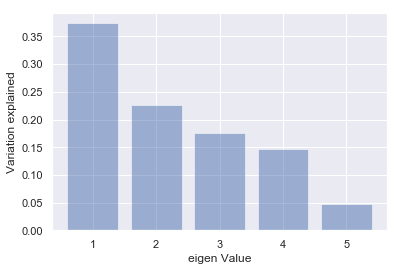

[0.9704526500042181, 0.9235881866058876, 0.7769904411465118, 0.6008110112504474, 0.3739102261426072]


In [1064]:
#Creating composite feature that has 95% of cumsum variance in it.
pca = PCA(n_components=5)
pca.fit(X_scaled)
#Individual explained variance
plt.bar(list(range(1,6)),pca.explained_variance_ratio_,alpha=0.5, align='center')
plt.ylabel('Variation explained')
plt.xlabel('eigen Value')
plt.show()
print(sorted(list(np.cumsum(pca.explained_variance_ratio_)), reverse=True))

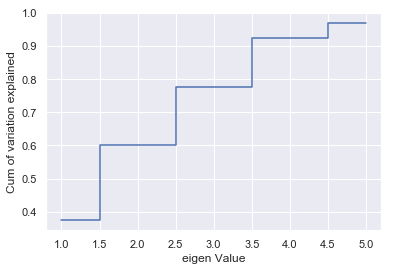

In [1065]:
#Cumulative explained variance
plt.step(list(range(1,6)),np.cumsum(pca.explained_variance_ratio_), where='mid')
plt.ylabel('Cum of variation explained')
plt.xlabel('eigen Value')
plt.show()

In [1066]:
b("==> Taking number of features where there is 95% of cumulative variance approximately in the above diagram. Feature composition can be created with having  6 dimensions as per above PC analysis. Hence, converting the overall features in to 6 attributes.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Taking number of features where there is 95% of cumulative variance approximately in the above diagram. Feature composition can be created with having  6 dimensions as per above PC analysis. Hence, converting the overall features in to 6 attributes. 


In [1067]:
X_pca = pca.transform(X_scaled)
df_pca = pd.DataFrame(X_pca)
print(df_pca.shape)

(1030, 5)


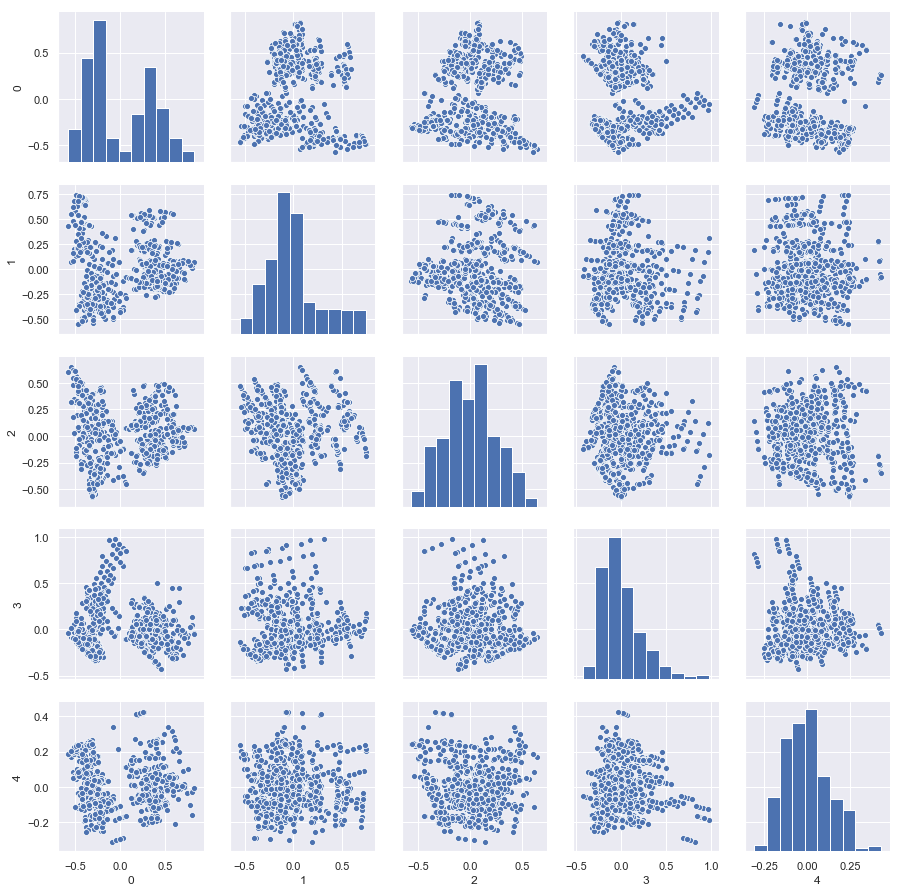

In [1068]:
sns.pairplot(df_pca);

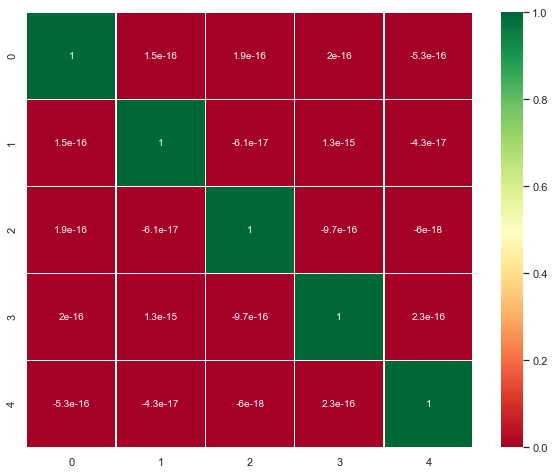

In [1069]:
df_pca.corr()
plt.figure(figsize=(10,8))
sns.heatmap(df_pca.corr(), annot=True, linewidth=0.5, cmap='RdYlGn')

In [1070]:
b("==> From the above head plot it is evident that all features are independent as relationship value is very close to zero.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> From the above head plot it is evident that all features are independent as relationship value is very close to zero. 


In [1071]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

In [1072]:
model_results = regressor_performance_metrics(algo_engines, "Max Absolute Scaler", "PCA(n_components=5) at 95% cumsum variance", X_train, y_train, X_test, y_test)
final_model_results = final_model_results.append(model_results.head(2), ignore_index=True)
model_results

,Model_Name,Scaling_Tech_Applied,FE_Tech_Applied,MAE,MSE,MSLE,RMSE,R2,Adjusted_R2,Model_Run_Duration_in_sec
0,XGBRegressor,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,4.263918,37.666760,0.047259,6.137325,0.842390,0.839789,0.086715
1,LGBMRegressor,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,4.768219,39.919522,0.048970,6.318190,0.832963,0.830207,0.081781
2,RandomForestRegressor,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,4.768422,42.359215,0.053384,6.508396,0.822755,0.81983,0.246341
3,GradientBoostingRegressor,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,5.268370,46.549194,0.055134,6.822697,0.805223,0.802008,0.145612
4,LGBMRegressor_CV,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,5.296441,56.660860,0.052734,7.527341,0.803101,None,0.402923
5,RandomForestRegressor_CV,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,5.275242,56.656246,0.055483,7.527034,0.802380,None,1.111029
6,XGBRegressor_CV,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,5.179603,58.519966,0.051150,7.649834,0.796933,None,0.444810
7,GradientBoostingRegressor_CV,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,5.728124,60.745332,0.061220,7.793929,0.789382,None,0.574576
8,BaggingRegressor,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,5.225380,50.538795,0.062489,7.109064,0.788529,0.785039,0.026927
9,BaggingRegressor_CV,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,5.528120,61.553815,0.061606,7.845624,0.784882,None,0.145573


### Approch # 5:
### Performing feature augmentation using Polynomial higher degree by keeping all 8 features

In [1073]:
# Copy only predictors. Keeping all 8 features as is.
X = df_org.iloc[:,0:-1]
# Copy only target column
y = df_org.iloc[:,-1:]
print(X.shape)
print(y.shape)

(1030, 8)
(1030, 1)


In [1074]:
# After performing polynomial feature augmentation with all features

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2, interaction_only=True)
scaler = preprocessing.MaxAbsScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_poly = poly.fit_transform(X_scaled)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

In [1075]:
print(X_poly.shape)
print(y.shape)

(1030, 37)
(1030, 1)


In [1076]:
model_results = regressor_performance_metrics(algo_engines, "Max Absolute Scaler", "PolynomialFeatures(degree=2)", X_train, y_train, X_test, y_test)
final_model_results = final_model_results.append(model_results.head(2), ignore_index=True)
model_results

,Model_Name,Scaling_Tech_Applied,FE_Tech_Applied,MAE,MSE,MSLE,RMSE,R2,Adjusted_R2,Model_Run_Duration_in_sec
0,LGBMRegressor,Max Absolute Scaler,PolynomialFeatures(degree=2),2.837807,16.764362,0.021599,4.094431,0.929852,0.920275,0.137632
1,XGBRegressor,Max Absolute Scaler,PolynomialFeatures(degree=2),2.882687,18.021200,0.021524,4.245138,0.924593,0.914298,0.164558
2,GradientBoostingRegressor,Max Absolute Scaler,PolynomialFeatures(degree=2),3.438239,20.508777,0.023996,4.528662,0.914184,0.902468,0.384998
3,LGBMRegressor_CV,Max Absolute Scaler,PolynomialFeatures(degree=2),3.376146,25.527814,0.021997,5.052506,0.912771,None,0.560502
4,RandomForestRegressor,Max Absolute Scaler,PolynomialFeatures(degree=2),3.319481,21.077575,0.025882,4.591032,0.911804,0.899763,0.803904
5,XGBRegressor_CV,Max Absolute Scaler,PolynomialFeatures(degree=2),3.454493,27.625351,0.023634,5.255982,0.905483,None,0.809837
6,GradientBoostingRegressor_CV,Max Absolute Scaler,PolynomialFeatures(degree=2),3.811502,27.688113,0.025859,5.261950,0.904943,None,1.612690
7,BaggingRegressor,Max Absolute Scaler,PolynomialFeatures(degree=2),3.532607,24.767527,0.029645,4.976698,0.896364,0.882215,0.084773
8,RandomForestRegressor_CV,Max Absolute Scaler,PolynomialFeatures(degree=2),3.825734,30.794791,0.027770,5.549305,0.894051,None,3.220340
9,BaggingRegressor_CV,Max Absolute Scaler,PolynomialFeatures(degree=2),4.110975,34.729470,0.031057,5.893171,0.880167,None,0.359039


In [1077]:
b("==> Increasing polynomial feature degree to more than 2 gives only little better results. So, it's good to keep the feature higher order to '2' to avoid model/dimension complexity. However, there are other models that perform well over Polynomial features.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Increasing polynomial feature degree to more than 2 gives only little better results. So, it's good to keep the feature higher order to '2' to avoid model/dimension complexity. However, there are other models that perform well over Polynomial features. 


In [1078]:
final_model_results = final_model_results.sort_values(by=['R2','Adjusted_R2'], ascending=False)
final_model_results

,Model_Name,Scaling_Tech_Applied,FE_Tech_Applied,MAE,MSE,MSLE,RMSE,R2,Adjusted_R2,Model_Run_Duration_in_sec
0,XGBRegressor,No Scaler,No FE. Used all 8 features,2.518013,14.556527,0.018671,3.815302,0.939091,0.937466,0.107714
1,LGBMRegressor,No Scaler,No FE. Used all 8 features,2.733912,15.696037,0.020857,3.961822,0.934323,0.932571,0.079787
8,LGBMRegressor,Max Absolute Scaler,PolynomialFeatures(degree=2),2.837807,16.764362,0.021599,4.094431,0.929852,0.920275,0.137632
9,XGBRegressor,Max Absolute Scaler,PolynomialFeatures(degree=2),2.882687,18.021200,0.021524,4.245138,0.924593,0.914298,0.164558
2,XGBRegressor,Max Absolute Scaler,No FE. Used all 8 features,2.992585,18.057825,0.022938,4.249450,0.924440,0.922425,0.074749
3,LGBMRegressor,Max Absolute Scaler,No FE. Used all 8 features,3.168884,19.254935,0.024550,4.388045,0.919431,0.917282,0.082779
4,XGBRegressor,Max Absolute Scaler,Dropping correlated feature 'water' manually,3.261541,19.660511,0.024468,4.434017,0.917734,0.915821,0.075798
5,LGBMRegressor,Max Absolute Scaler,Dropping correlated feature 'water' manually,3.464042,20.545538,0.024845,4.532719,0.914031,0.912031,0.078789
6,XGBRegressor,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,4.263918,37.666760,0.047259,6.137325,0.842390,0.839789,0.086715
7,LGBMRegressor,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,4.768219,39.919522,0.048970,6.318190,0.832963,0.830207,0.081781


In [1079]:
b("==> Above tabular shows top 2 models taken from each approach (i.e from approach # 1 to 5) based on R2/adjusted R2 and its cross validation score and model run duration.\n==> Based on the above model performance report, it is evident that LGBM and XGB regressor engines perform well consistently.\n==>Interestingly, these top models performs well on the original raw dataset over processed dataset(like scaled/fe'd), \n==>Also, in the following steps, I'd perform hyper paramter tuning on these top 2 models and see if accuracy score imporoves.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Above tabular shows top 2 models taken from each approach (i.e from approach # 1 to 5) based on R2/adjusted R2 and its cross validation score and model run duration.
==> Based on the above model performance report, it is evident that LGBM and XGB regressor engines perform well consistently.
==>Interestingly, these top models performs well on the original raw dataset over processed dataset(like scaled/fe'd), 
==>Also, in the following steps, I'd perform hyper paramter tuning on these top 2 models and see if accuracy score imporoves. 


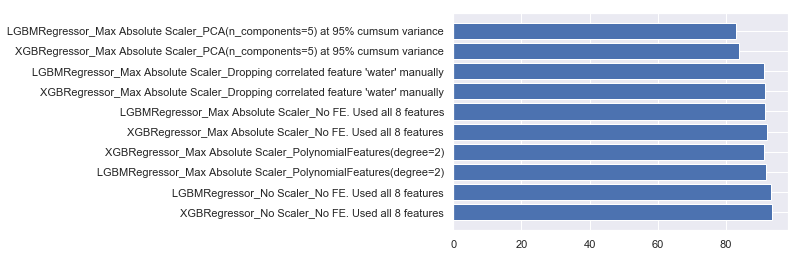

In [1080]:
plt.barh(final_model_results.Model_Name+"_"+final_model_results.Scaling_Tech_Applied+"_"+final_model_results.FE_Tech_Applied, final_model_results.Adjusted_R2*100)
plt.show()

### c. Explore for gaussians. If data is likely to be a mix of gaussians, explore individual clusters and present your findings in terms of the independent attributes and their suitability to predict strength

In [1081]:
#Grouping the above data into similar clusters
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

# Copy only predictors. Keeping all 8 features as is.
X = df_org.iloc[:,0:-1]
# Copy only target column
y = df_org.iloc[:,-1:]
print(X.shape)
print(y.shape)

#Scaling the data
scaler = preprocessing.MaxAbsScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

(1030, 8)
(1030, 1)


Text(0.5,1,'Selecting k with the Elbow Method')

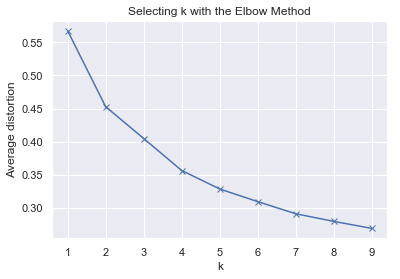

In [1082]:
clusters=range(1,10)
meanDistortions=[]

for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(X_scaled)
    pred = model.predict(X_scaled)
    meanDistortions.append(sum(np.min(cdist(X_scaled, model.cluster_centers_, 'euclidean'), axis=1)) / X_scaled.shape[0])

plt.plot(clusters, meanDistortions, 'bx-');
plt.xlabel('k')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')

In [1083]:
b("==> From the above elbow plot, I'm taking 4 as a best 'K' value i.e. data can be clustered in to 4 groups to check the data distribution in the clusters")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> From the above elbow plot, I'm taking 4 as a best 'K' value i.e. data can be clustered in to 4 groups to check the data distribution in the clusters 


In [1097]:
final_model=KMeans(n_clusters = 4)
final_model.fit(X_scaled)
pred = final_model.predict(X_scaled)

#Append the prediction 
X["cluster_number"] = pred
X_scaled["cluster_number"] = pred
#There are four clusters created
X.cluster_number.unique()

array([1, 0, 3, 2], dtype=int64)

In [1098]:
X_clusters = X.groupby(['cluster_number'])
X_clusters.mean()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
cluster_number,,,,,,,,
0,240.175621,40.587585,124.028894,175.260835,8.915350,969.008578,784.203612,33.453725
1,276.162593,172.135741,1.088889,177.885926,7.385926,951.755556,774.793611,22.300000
2,363.449714,2.348571,0.680000,188.888000,0.666286,1020.068000,767.022286,17.560000
3,317.165493,79.159859,3.212676,199.045070,1.996479,967.252113,745.192958,107.735915


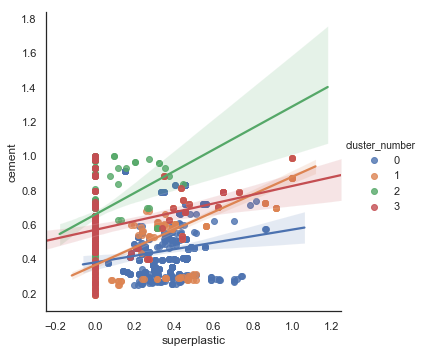

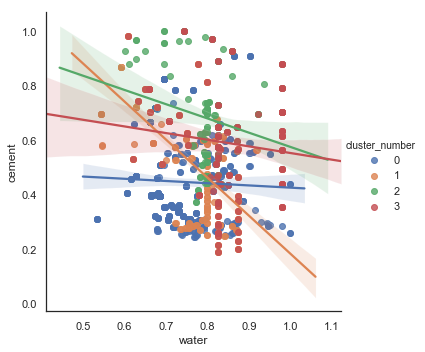

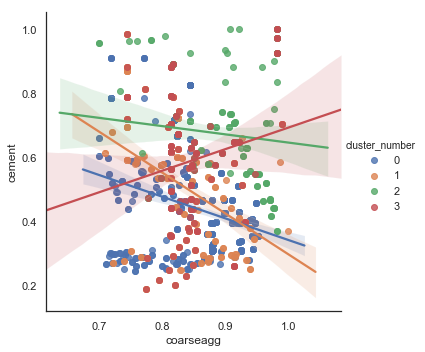

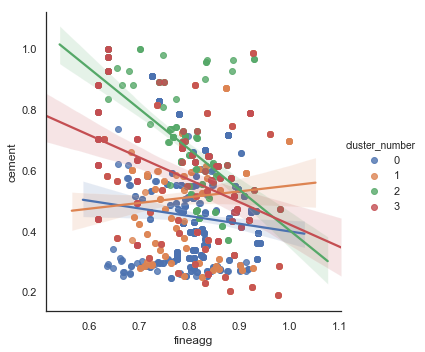

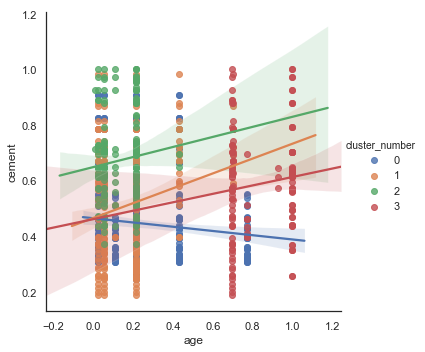

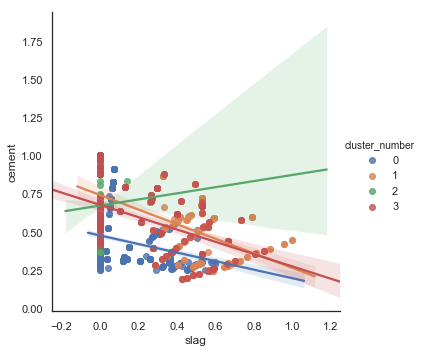

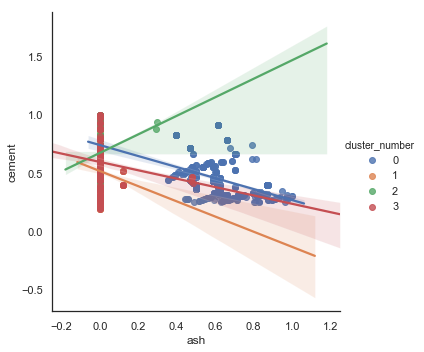

In [1116]:
with sns.axes_style("white"):
    plot = sns.lmplot('superplastic','cement', data=X_scaled, hue='cluster_number')
    plot = sns.lmplot('water','cement', data=X_scaled, hue='cluster_number')
    plot = sns.lmplot('coarseagg','cement', data=X_scaled, hue='cluster_number')
    plot = sns.lmplot('fineagg','cement', data=X_scaled, hue='cluster_number')
    plot = sns.lmplot('age','cement', data=X_scaled, hue='cluster_number')
    plot = sns.lmplot('slag','cement', data=X_scaled, hue='cluster_number')
    plot = sns.lmplot('ash','cement', data=X_scaled, hue='cluster_number')

In [1117]:
#Group by cluster_name and row counts of each cluster
X_scaled.groupby(['cluster_number']).count()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
cluster_number,,,,,,,,
0,443,443,443,443,443,443,443,443
1,270,270,270,270,270,270,270,270
2,175,175,175,175,175,175,175,175
3,142,142,142,142,142,142,142,142


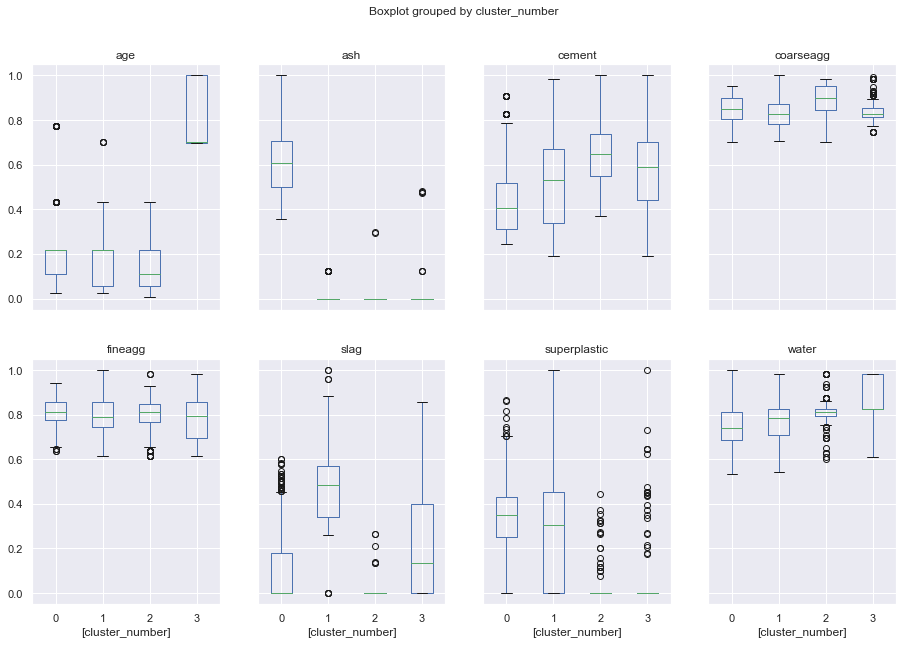

In [1118]:
X_scaled.boxplot(by='cluster_number', layout = (2,4),figsize=(15,10));

In [1119]:
b("==> From the above group by 'cluster_name' table and cluster wise data distribution of each attribute, I can make below observations,\n==> There are 270 observations grouped in to cluser # 1; 447 observations in cluster # 2; 138 observations in cluster # 3; 175 observations in cluster # 4.\n==> Attribute 'age' from cluster# 3 contains only higher values and so other attributes in the same cluster with right and left skewness across different attributes along with plenty of outliers on the upper/right tail except 'ash'.\n==> Attribute 'ash' of cluster # 2 is extremely high where are other clusters have minimal 'ash' values. ==> Only 'cement' and 'fineagg' attributes are approximately normally distributes data pattern in it. Other attributes doesn't have any identical distribution in it.\n==> With this, I couldn't clearly identify which cluster gives some meaningful business inference.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> From the above group by 'cluster_name' table and cluster wise data distribution of each attribute, I can make below observations,
==> There are 270 observations grouped in to cluser # 1; 447 observations in cluster # 2; 138 observations in cluster # 3; 175 observations in cluster # 4.
==> Attribute 'age' from cluster# 3 contains only higher values and so other attributes in the same cluster with right and left skewness across different attributes along with plenty of outliers on the upper/right tail except 'ash'.
==> Attribute 'ash' of cluster # 2 is extremely high where are other clusters have minimal 'ash' values. ==> Only 'cement' and 'fineagg' attributes are approximately normally distributes data pattern in it. Other att

# 3. Deliverable -3 (create the model )

### a. Obtain feature importance for the individual features and present your findings

In [1120]:
# Copy only predictors. Keeping all 8 features as is.
X = df_org.iloc[:,0:-1]
# Copy only target column
y = df_org.iloc[:,-1:]
print(X.shape)
print(y.shape)

(1030, 8)
(1030, 1)


In [1121]:
#Didn't apply any scaler technique. Trying on raw data as is.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)

In [1122]:
# Defining predictor engines for each algo
ols_lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso()
svr = svm.SVR(kernel='linear')
dtr = DecisionTreeRegressor()
br = BaggingRegressor()
rf = RandomForestRegressor()
gbr = GradientBoostingRegressor()
xgbr = XGBRegressor()
lgbmr = LGBMRegressor()
# knnr = KNeighborsRegressor() --> No direct function available. Unable to find coefficient in a simplest way. Needs more effort.
algo_engines = [ols_lr, ridge, lasso, svr, dtr,br, rf, gbr, xgbr, lgbmr]

In [1123]:
#Regression model evalution metrics
def regressor_feature_importance(predictor_name, X_train, y_train, X_test, y_test):
    df_feature_imp = pd.DataFrame(columns = list(X.columns))
    for algo_eng in predictor_name:
        start_time = time()
        algo_eng.fit(X_train, y_train)
        if algo_eng in [lasso, knnr]:
            feature_score = algo_eng.coef_.reshape(1, -1)
        elif algo_eng in [dtr, rf, gbr, xgbr, lgbmr]:
            feature_score = algo_eng.feature_importances_.reshape(1, -1)
        elif algo_eng in [br]:
            feature_score = np.mean([tree.feature_importances_ for tree in algo_eng.estimators_], axis=0).reshape(1,-1)
        else:
            feature_score = algo_eng.coef_
        print(feature_score)
        df_feature_imp_add = pd.DataFrame(feature_score, columns = list(X.columns), index=[str(algo_eng).split('(')[0]+"_Feature_Importance_Score"])
        df_feature_imp = df_feature_imp.append(df_feature_imp_add)
        del df_feature_imp_add
    return df_feature_imp

In [1124]:
#calling regressor_feature_importance method,
algo_wise_feature_importance = regressor_feature_importance(algo_engines, X_train, y_train, X_test, y_test)
algo_wise_feature_importance

[[ 0.11480092  0.09404981  0.07490483 -0.17491424  0.27303235  0.00758222
   0.01161374  0.2612693 ]]
[[ 0.11480109  0.09405005  0.07490562 -0.17491923  0.27300338  0.00758147
   0.01161349  0.2612691 ]]
[[ 0.11324318  0.09219222  0.07400049 -0.19401002  0.1999282   0.00371629
   0.00855092  0.26049236]]
[[ 0.11487964  0.08831607  0.07440598 -0.12728498  0.38606294  0.01024653
   0.00966596  0.27203718]]
[[0.36518775 0.10187326 0.00797618 0.1060067  0.04438873 0.02856492
  0.0271857  0.31881676]]
[[0.31750182 0.08249832 0.013001   0.10343017 0.07582074 0.02482368
  0.03640584 0.34651843]]
[[0.31598137 0.07704726 0.01662195 0.09319088 0.07683948 0.03233859
  0.03478454 0.35319592]]
[[0.30256978 0.07344393 0.00963127 0.09890091 0.07478958 0.01963802
  0.04126858 0.37975793]]
[[0.23958468 0.12759595 0.03253144 0.10410987 0.17006347 0.03295593
  0.04391671 0.24924193]]
[[429 293 119 423 273 449 420 266]]


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
LinearRegression_Feature_Importance_Score,0.114801,0.094050,0.074905,-0.174914,0.273032,0.007582,0.011614,0.261269
Ridge_Feature_Importance_Score,0.114801,0.094050,0.074906,-0.174919,0.273003,0.007581,0.011613,0.261269
Lasso_Feature_Importance_Score,0.113243,0.092192,0.074000,-0.194010,0.199928,0.003716,0.008551,0.260492
SVR_Feature_Importance_Score,0.114880,0.088316,0.074406,-0.127285,0.386063,0.010247,0.009666,0.272037
DecisionTreeRegressor_Feature_Importance_Score,0.365188,0.101873,0.007976,0.106007,0.044389,0.028565,0.027186,0.318817
BaggingRegressor_Feature_Importance_Score,0.317502,0.082498,0.013001,0.103430,0.075821,0.024824,0.036406,0.346518
RandomForestRegressor_Feature_Importance_Score,0.315981,0.077047,0.016622,0.093191,0.076839,0.032339,0.034785,0.353196
GradientBoostingRegressor_Feature_Importance_Score,0.302570,0.073444,0.009631,0.098901,0.074790,0.019638,0.041269,0.379758
XGBRegressor_Feature_Importance_Score,0.239585,0.127596,0.032531,0.104110,0.170063,0.032956,0.043917,0.249242
LGBMRegressor_Feature_Importance_Score,429.000000,293.000000,119.000000,423.000000,273.000000,449.000000,420.000000,266.000000


In [1125]:
# Mean value of each feature calculated from different model's feature importances/coefficients
algo_wise_feature_importance.mean()

cement          43.099855
slag            29.383107
ash             11.937798
water           42.283451
superplastic    27.457393
coarseagg       44.916745
fineagg         42.022501
age             26.870260
dtype: float64

In [1126]:
b("==> Beyond each model's feature importance, there is an average feature importance calculated as captured in the above commandline output.\n==> From the above mean feature importance results, it is evident that attributes such as 'cement', 'coarseagg', 'fineagg','water/superplastic', 'age' are contributing significantly.\n==> Also, a point to note that LGBMRegressor's feature importance is much different from other regressor's feature importance score. May be, that's uniqueness of LGBRegressor that it performs really well in terms of predictions over other models as we witnessed in 'Deliverable-2'")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> Beyond each model's feature importance, there is an average feature importance calculated as captured in the above commandline output.
==> From the above mean feature importance results, it is evident that attributes such as 'cement', 'coarseagg', 'fineagg','water/superplastic', 'age' are contributing significantly.
==> Also, a point to note that LGBMRegressor's feature importance is much different from other regressor's feature importance score. May be, that's uniqueness of LGBRegressor that it performs really well in terms of predictions over other models as we witnessed in 'Deliverable-2' 


# 4. Deliverable -4 (Tuning the model)

### a. Algorithms that you think will be suitable for this project

In [1127]:
#Model performance results from Deliverable-2
final_model_results

,Model_Name,Scaling_Tech_Applied,FE_Tech_Applied,MAE,MSE,MSLE,RMSE,R2,Adjusted_R2,Model_Run_Duration_in_sec
0,XGBRegressor,No Scaler,No FE. Used all 8 features,2.518013,14.556527,0.018671,3.815302,0.939091,0.937466,0.107714
1,LGBMRegressor,No Scaler,No FE. Used all 8 features,2.733912,15.696037,0.020857,3.961822,0.934323,0.932571,0.079787
8,LGBMRegressor,Max Absolute Scaler,PolynomialFeatures(degree=2),2.837807,16.764362,0.021599,4.094431,0.929852,0.920275,0.137632
9,XGBRegressor,Max Absolute Scaler,PolynomialFeatures(degree=2),2.882687,18.021200,0.021524,4.245138,0.924593,0.914298,0.164558
2,XGBRegressor,Max Absolute Scaler,No FE. Used all 8 features,2.992585,18.057825,0.022938,4.249450,0.924440,0.922425,0.074749
3,LGBMRegressor,Max Absolute Scaler,No FE. Used all 8 features,3.168884,19.254935,0.024550,4.388045,0.919431,0.917282,0.082779
4,XGBRegressor,Max Absolute Scaler,Dropping correlated feature 'water' manually,3.261541,19.660511,0.024468,4.434017,0.917734,0.915821,0.075798
5,LGBMRegressor,Max Absolute Scaler,Dropping correlated feature 'water' manually,3.464042,20.545538,0.024845,4.532719,0.914031,0.912031,0.078789
6,XGBRegressor,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,4.263918,37.666760,0.047259,6.137325,0.842390,0.839789,0.086715
7,LGBMRegressor,Max Absolute Scaler,PCA(n_components=5) at 95% cumsum variance,4.768219,39.919522,0.048970,6.318190,0.832963,0.830207,0.081781


In [1128]:
b("As i explored different models and its performances, I'd go with top two models that are LGBMRegressor and XGBRegressor and would apply some performance tuning techniques to get extra prediction performance.\n==> Note: For this project, I'm not much worrying about the model run duration is very short for all explored models as the dataset is much smaller.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 As i explored different models and its performances, I'd go with top two models that are LGBMRegressor and XGBRegressor and would apply some performance tuning techniques to get extra prediction performance.
==> Note: For this project, I'm not much worrying about the model run duration is very short for all explored models as the dataset is much smaller. 


### b. Techniques employed to squeeze that extra performance out of the model without making it overfit or underfit

In [1129]:
#I'll primarily focus on top two models that are LGBM and XGB regressors and apply hyper parameter tuning and cross validations

# Copy only predictors. Keeping all 8 features as is.
X = df_org.iloc[:,0:-1]
# Copy only target column
y = df_org.iloc[:,-1:]
print(X.shape)
print(y.shape)

# X = df_org[['cement', 'slag', 'ash', 'superplastic', 'coarseagg', 'fineagg','age' ]]
# y = df_org['strength']
# print(X.shape)
# print(y.shape)

(1030, 8)
(1030, 1)


In [1130]:
#Using best scaler after comparing with other scalers
scaler = preprocessing.MaxAbsScaler()
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.3, random_state=random_st, stratify=stratify_ind)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=random_st, stratify=stratify_ind)

In [1131]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(721, 8)
(154, 8)
(155, 8)


### Parameter tuning and performance evaludation on LGBM regressor

In [1132]:
from sklearn.pipeline import Pipeline

#creating pipeline with scaler & lgbm regressor engine
pipe_lgbmr = Pipeline([("scaler", scaler), ("lgbmr", LGBMRegressor())])
pipe_lgbmr.fit(X_train, y_train)
print(" Train score: {:.2f}". format( pipe.score( X_train, y_train)))
print(" Test score: {:.2f}". format( pipe.score( X_test, y_test)))

 Train score: 0.97
 Test score: 0.93


In [1133]:
#regressor object instantiation
xgbr = XGBRegressor()
lgbmr = LGBMRegressor()
# xgbr.get_params()
# xgbr.get_params().keys()

In [877]:
# Identifying best parameters to be used in the regression engine to avoid the above overfitting

# param = {'learning_rate':list(range(0.01,3.0,0.1)), 'max_depth':2, 'min_child_samples':3, 'min_child_weight':list(range(0.001,0.5,0.001)),'random_state':random_st, 'reg_alpha':list(range(1.0,5.0,0.5))}
param = {
    'boosting_type': ['gbdt','dart','goss','rf'],
    'num_leaves': [30, 40],
    'reg_alpha': [1e-5, 1e-2, 0.1, 1, 100],
    'min_data_in_leaf': [50, 100, 300, 400],
    'lambda_l1': [0, 1, 1.5],
    'lambda_l2': [0, 1, 2, 3]
    }

gridsrc = GridSearchCV(lgbmr, param, cv=5, n_jobs = -1, verbose = 2)
randomsrc = RandomizedSearchCV(lgbmr, param_distributions=param, cv=5, n_jobs = -1, verbose = 2)

st = time()
print("start time: ",st)
gridsrc.fit(X_train, y_train)
randomsrc.fit(X_train, y_train)
et = time()
print(" end time: ",et)
print("total time taken for grid and random param search: ",et-st)

print("Grid Search best parameters: ", gridsrc.best_params_)
print("Random Search best parameters: ", randomsrc.best_params_)

start time:  1608150946.0222354
Fitting 5 folds for each of 1920 candidates, totalling 9600 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 580 tasks      | elapsed:    9.5s
[Parallel(n_jobs=-1)]: Done 2204 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-1)]: Done 4468 tasks      | elapsed:   54.7s
[Parallel(n_jobs=-1)]: Done 7388 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 9600 out of 9600 | elapsed:  1.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=1e-05 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
Fitting 5 folds for each of 10 candidates, totalling 50 fits
 end time:  1608151035.763375
total time taken for grid and random param search:  89.74113965034485
Grid Search best parameters:  {'boosting_type': 'gbdt', 'lambda_l1': 0, 'lambda_l2': 0, 'min_data_in_leaf': 50, 'num_leaves': 30, 'reg_alpha': 1e-05}
Random Search best parameters:  {'reg_alpha': 1e-05, 'num_leaves': 40, 'min_data_in_leaf': 50, 'lambda_l2': 0, 'lambda_l1': 1.5, 'boosting_type': 'gbdt'}


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.5s finished


In [878]:
gridsrc.cv_results_['params']

[{'boosting_type': 'gbdt',
  'lambda_l1': 0,
  'lambda_l2': 0,
  'min_data_in_leaf': 50,
  'num_leaves': 30,
  'reg_alpha': 1e-05},
 {'boosting_type': 'gbdt',
  'lambda_l1': 0,
  'lambda_l2': 0,
  'min_data_in_leaf': 50,
  'num_leaves': 30,
  'reg_alpha': 0.01},
 {'boosting_type': 'gbdt',
  'lambda_l1': 0,
  'lambda_l2': 0,
  'min_data_in_leaf': 50,
  'num_leaves': 30,
  'reg_alpha': 0.1},
 {'boosting_type': 'gbdt',
  'lambda_l1': 0,
  'lambda_l2': 0,
  'min_data_in_leaf': 50,
  'num_leaves': 30,
  'reg_alpha': 1},
 {'boosting_type': 'gbdt',
  'lambda_l1': 0,
  'lambda_l2': 0,
  'min_data_in_leaf': 50,
  'num_leaves': 30,
  'reg_alpha': 100},
 {'boosting_type': 'gbdt',
  'lambda_l1': 0,
  'lambda_l2': 0,
  'min_data_in_leaf': 50,
  'num_leaves': 40,
  'reg_alpha': 1e-05},
 {'boosting_type': 'gbdt',
  'lambda_l1': 0,
  'lambda_l2': 0,
  'min_data_in_leaf': 50,
  'num_leaves': 40,
  'reg_alpha': 0.01},
 {'boosting_type': 'gbdt',
  'lambda_l1': 0,
  'lambda_l2': 0,
  'min_data_in_leaf': 5

In [879]:
sorted(list(gridsrc.cv_results_['mean_test_score']), reverse=True)

[0.8916652215001729,
 0.8916652215001729,
 0.8916652215001729,
 0.8916652215001729,
 0.8916652215001729,
 0.8916652215001729,
 0.8916652215001729,
 0.8916652215001729,
 0.8916652215001729,
 0.8916652215001729,
 0.8914716025102862,
 0.8914716025102862,
 0.8914716025102862,
 0.8914716025102862,
 0.8914716025102862,
 0.8914716025102862,
 0.8914716025102862,
 0.8914716025102862,
 0.8914716025102862,
 0.8914716025102862,
 0.8911588109164359,
 0.8911588109164359,
 0.8911588109164359,
 0.8911588109164359,
 0.8911588109164359,
 0.8911588109164359,
 0.8911588109164359,
 0.8911588109164359,
 0.8911588109164359,
 0.8911588109164359,
 0.8904975277640652,
 0.8904975277640652,
 0.8904975277640652,
 0.8904975277640652,
 0.8904975277640652,
 0.8904975277640652,
 0.8904975277640652,
 0.8904975277640652,
 0.8904975277640652,
 0.8904975277640652,
 0.8900498650837267,
 0.8900498650837267,
 0.8900498650837267,
 0.8900498650837267,
 0.8900498650837267,
 0.8900498650837267,
 0.8900498650837267,
 0.8900498650

In [880]:
randomsrc.cv_results_['params']

[{'reg_alpha': 1e-05,
  'num_leaves': 40,
  'min_data_in_leaf': 50,
  'lambda_l2': 0,
  'lambda_l1': 1.5,
  'boosting_type': 'gbdt'},
 {'reg_alpha': 0.01,
  'num_leaves': 40,
  'min_data_in_leaf': 300,
  'lambda_l2': 2,
  'lambda_l1': 0,
  'boosting_type': 'goss'},
 {'reg_alpha': 1e-05,
  'num_leaves': 30,
  'min_data_in_leaf': 100,
  'lambda_l2': 3,
  'lambda_l1': 1,
  'boosting_type': 'rf'},
 {'reg_alpha': 0.1,
  'num_leaves': 30,
  'min_data_in_leaf': 50,
  'lambda_l2': 1,
  'lambda_l1': 1.5,
  'boosting_type': 'dart'},
 {'reg_alpha': 100,
  'num_leaves': 40,
  'min_data_in_leaf': 400,
  'lambda_l2': 0,
  'lambda_l1': 0,
  'boosting_type': 'rf'},
 {'reg_alpha': 1,
  'num_leaves': 30,
  'min_data_in_leaf': 50,
  'lambda_l2': 0,
  'lambda_l1': 1.5,
  'boosting_type': 'goss'},
 {'reg_alpha': 1e-05,
  'num_leaves': 40,
  'min_data_in_leaf': 300,
  'lambda_l2': 2,
  'lambda_l1': 0,
  'boosting_type': 'gbdt'},
 {'reg_alpha': 1e-05,
  'num_leaves': 40,
  'min_data_in_leaf': 400,
  'lambda_

In [881]:
sorted(list(randomsrc.cv_results_['mean_test_score']), reverse=True)

[0.8914716025102862,
 nan,
 0.7851414872961906,
 nan,
 0.8144574829707514,
 0.7226689516543733,
 -0.003853509982259462,
 -0.003853509982259462,
 -0.003853509982259462,
 -0.003853509982259462]

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] lambda_l1 is set=0, reg_alpha=1e-05 will be ignored. Current value: lambda_l1=0
[LightGBM] [Warning] lambda_l2 is set=0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0
Train score: 0.97
Validation score: 0.94
Test score: 0.93


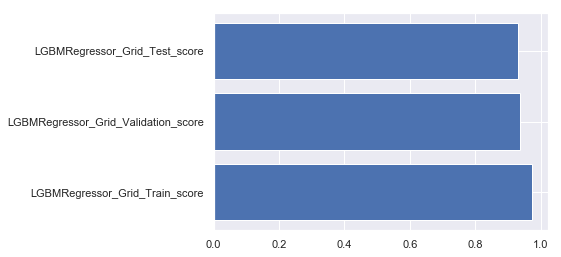

In [1134]:

#Passing grid search's best params
pipe_lgbmr_grid = Pipeline([("scaler", scaler), ("lgbmr", LGBMRegressor(n_estimators=270, boosting_type= 'gbdt', lambda_l1= 0, lambda_l2= 0, min_data_in_leaf= 50, num_leaves= 30, reg_alpha= 1e-05, random_state=random_st))])
pipe_lgbmr_grid.fit(X_train, y_train)
print("Train score: {:.2f}". format(pipe_lgbmr_grid.score(X_train, y_train)))
print("Validation score: {:.2f}". format(pipe_lgbmr_grid.score(X_val, y_val)))
print("Test score: {:.2f}". format(pipe_lgbmr_grid.score(X_test, y_test)))
plt.barh(['LGBMRegressor_Grid_Train_score', 'LGBMRegressor_Grid_Validation_score', 'LGBMRegressor_Grid_Test_score'],[pipe_lgbmr_grid.score(X_train, y_train), pipe_lgbmr_grid.score(X_val, y_val), pipe_lgbmr_grid.score(X_test, y_test)])
plt.show()

[LightGBM] [Warning] min_data_in_leaf is set=50, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=50
[LightGBM] [Warning] lambda_l1 is set=1.5, reg_alpha=1e-05 will be ignored. Current value: lambda_l1=1.5
[LightGBM] [Warning] lambda_l2 is set=1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1
Train score: 0.97
Validation score: 0.93
Test score: 0.93


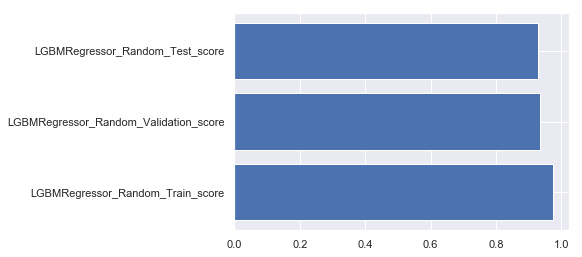

In [1135]:
#Passing random search's best params
pipe_lgbmr_random = Pipeline([("scaler", scaler), ("lgbmr", LGBMRegressor(n_estimators=290, reg_alpha= 1e-05, num_leaves= 40, min_data_in_leaf= 50, lambda_l2= 1, lambda_l1= 1.5, boosting_type= 'gbdt', random_state=random_st))])
pipe_lgbmr_random.fit(X_train, y_train)
print("Train score: {:.2f}". format(pipe_lgbmr_random.score(X_train, y_train)))
print("Validation score: {:.2f}". format(pipe_lgbmr_random.score(X_val, y_val)))
print("Test score: {:.2f}". format(pipe_lgbmr_random.score(X_test, y_test)))
plt.barh(['LGBMRegressor_Random_Train_score', 'LGBMRegressor_Random_Validation_score', 'LGBMRegressor_Random_Test_score'],[pipe_lgbmr_random.score(X_train, y_train), pipe_lgbmr_random.score(X_val, y_val), pipe_lgbmr_random.score(X_test, y_test)])
plt.show()

In [1136]:
b("==> From the above grid and random searches, it seems grid search gives better results during validation however, the performance on the test data is same across different parameter tuning techniques.\n==> Slightly, there is an overfit in the model. However, I choose Grid Search  parameters for LGBM regressor as inputs.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> From the above grid and random searches, it seems grid search gives better results during validation however, the performance on the test data is same across different parameter tuning techniques.
==> Slightly, there is an overfit in the model. However, I choose Grid Search  parameters for LGBM regressor as inputs. 


### c. Model performance range at 95% confidence level

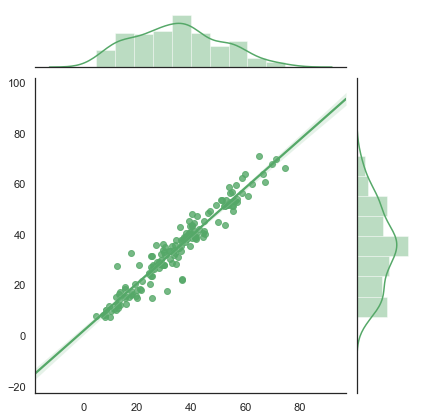

In [1137]:
#95% confidence level with 5% of error in the model
sns.set(style="darkgrid", color_codes=True)
y_pred = pipe_lgbmr_grid.predict(X_test)
with sns.axes_style("white"):
    sns.jointplot(x=y_test.strength.tolist(), y=y_pred.tolist(), kind="reg", color="g");

### Parameter tuning and performance evaludation on XGB regressor

In [1138]:
#Parameter tuning and performance evaludation on XGB regressor

#creating pipeline with scaler & xgb regressor engine
pipe_xgbr = Pipeline([("scaler", scaler), ("xgbr", XGBRegressor())])
pipe_xgbr.fit(X_train, y_train)
print("Train score: {:.2f}". format(pipe.score( X_train, y_train)))
print("Test score: {:.2f}". format(pipe.score( X_test, y_test)))

Train score: 0.97
Test score: 0.93


In [1139]:
# Identifying best parameters to be used in the regression engine to avoid the above overfitting

# param = {'learning_rate':list(range(0.01,3.0,0.1)), 'max_depth':2, 'min_child_samples':3, 'min_child_weight':list(range(0.001,0.5,0.001)),'random_state':random_st, 'reg_alpha':list(range(1.0,5.0,0.5))}
param = {
     'subsample':[i/10.0 for i in range(6,10)],
     'colsample_bytree':[i/10.0 for i in range(6,10)],
     'min_child_weight':[6,8,10,12],
     'max_depth':range(3,10,2),
     'min_child_weight':range(1,6,2),
     'learning_rate': [0.1, 0.5, 1.0]
    }

gridsrc = GridSearchCV(xgbr, param, cv=5, n_jobs = -1, verbose = 2)
randomsrc = RandomizedSearchCV(xgbr, param_distributions=param, cv=5, n_jobs = -1, verbose = 2)

st = time()
print("start time: ",st)
gridsrc.fit(X_train, y_train)
randomsrc.fit(X_train, y_train)
et = time()
print(" end time: ",et)
print("total time taken for grid and random param search: ",et-st)

print("Grid Search best parameters: ", gridsrc.best_params_)
print("Random Search best parameters: ", randomsrc.best_params_)

start time:  1608156200.8755732
Fitting 5 folds for each of 576 candidates, totalling 2880 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 tasks      | elapsed:    4.7s
[Parallel(n_jobs=-1)]: Done 492 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-1)]: Done 1304 tasks      | elapsed:   37.4s
[Parallel(n_jobs=-1)]: Done 2436 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 2880 out of 2880 | elapsed:  1.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


Fitting 5 folds for each of 10 candidates, totalling 50 fits
 end time:  1608156292.7509525
total time taken for grid and random param search:  91.87537932395935
Grid Search best parameters:  {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 5, 'subsample': 0.7}
Random Search best parameters:  {'subsample': 0.6, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    1.5s finished


In [1140]:
gridsrc.cv_results_['params']

[{'colsample_bytree': 0.6,
  'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 1,
  'subsample': 0.6},
 {'colsample_bytree': 0.6,
  'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 1,
  'subsample': 0.7},
 {'colsample_bytree': 0.6,
  'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 1,
  'subsample': 0.8},
 {'colsample_bytree': 0.6,
  'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 1,
  'subsample': 0.9},
 {'colsample_bytree': 0.6,
  'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 3,
  'subsample': 0.6},
 {'colsample_bytree': 0.6,
  'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 3,
  'subsample': 0.7},
 {'colsample_bytree': 0.6,
  'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 3,
  'subsample': 0.8},
 {'colsample_bytree': 0.6,
  'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 3,
  'subsample': 0.9},
 {'colsample_bytree': 0.6,
  'learning_rate': 0.1,
  'max_depth': 3,
  'min_chil

In [1141]:
sorted(list(gridsrc.cv_results_['mean_test_score']), reverse=True)

[0.9238154935566874,
 0.9233053050276286,
 0.923186854088757,
 0.922953329780745,
 0.9227633874926557,
 0.9226842256161639,
 0.9225359026513924,
 0.9221367974509038,
 0.921984159661176,
 0.9216285118791454,
 0.9211648254502943,
 0.9211082173174656,
 0.9206541166589808,
 0.9206342604797794,
 0.9206155923340742,
 0.9205846975465262,
 0.920579130417034,
 0.9204815096996395,
 0.9203026682842369,
 0.9202046521809821,
 0.9201503100522412,
 0.9199714346330137,
 0.9198315351561547,
 0.9197750637137562,
 0.9197194278903644,
 0.9196395061257112,
 0.9196378301934303,
 0.9189569808410003,
 0.9189476973624726,
 0.918797419719102,
 0.9187361161869552,
 0.9185335284922006,
 0.9183818020802269,
 0.9183206672589609,
 0.918188587790338,
 0.9181150335180346,
 0.9180005742214898,
 0.9179000962577755,
 0.9177408786478708,
 0.9177059354052381,
 0.9176188436373938,
 0.9176084770551972,
 0.9175238827420081,
 0.917435234415889,
 0.9173897564956206,
 0.9173599069523612,
 0.9173134435002692,
 0.917258300120297,


In [1142]:
randomsrc.cv_results_['params']

[{'subsample': 0.6,
  'min_child_weight': 5,
  'max_depth': 3,
  'learning_rate': 0.5,
  'colsample_bytree': 0.8},
 {'subsample': 0.9,
  'min_child_weight': 3,
  'max_depth': 3,
  'learning_rate': 0.1,
  'colsample_bytree': 0.7},
 {'subsample': 0.9,
  'min_child_weight': 3,
  'max_depth': 5,
  'learning_rate': 0.5,
  'colsample_bytree': 0.9},
 {'subsample': 0.6,
  'min_child_weight': 1,
  'max_depth': 7,
  'learning_rate': 0.1,
  'colsample_bytree': 0.7},
 {'subsample': 0.7,
  'min_child_weight': 3,
  'max_depth': 3,
  'learning_rate': 0.1,
  'colsample_bytree': 0.8},
 {'subsample': 0.7,
  'min_child_weight': 3,
  'max_depth': 5,
  'learning_rate': 0.5,
  'colsample_bytree': 0.7},
 {'subsample': 0.6,
  'min_child_weight': 1,
  'max_depth': 9,
  'learning_rate': 0.5,
  'colsample_bytree': 0.7},
 {'subsample': 0.7,
  'min_child_weight': 5,
  'max_depth': 9,
  'learning_rate': 1.0,
  'colsample_bytree': 0.9},
 {'subsample': 0.9,
  'min_child_weight': 5,
  'max_depth': 9,
  'learning_rate'

In [1143]:
sorted(list(randomsrc.cv_results_['mean_test_score']), reverse=True)

[0.9177408786478708,
 0.9020913906464498,
 0.8957652085426673,
 0.8931337364193054,
 0.8916855959435569,
 0.8900904325176976,
 0.8899770219388661,
 0.8580421782143797,
 0.7965568796528092,
 0.7513315030163026]

Train score: 0.96
Validation score: 0.93
Test score: 0.91


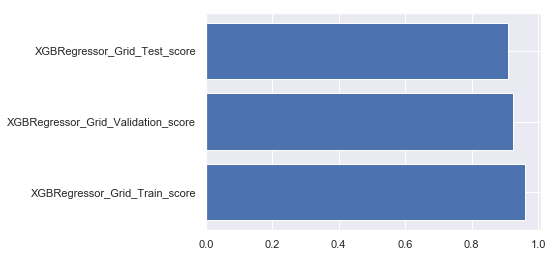

In [1144]:
#Passing grid search's best params
pipe_xgbr_grid = Pipeline([("scaler", scaler), ("xgbr", XGBRegressor(n_estimators=147, colsample_bytree= 0.9, learning_rate= 0.0899, max_depth= 3, min_child_weight= 4, subsample= 0.7, random_state=random_st))])
pipe_xgbr_grid.fit(X_train, y_train)
print("Train score: {:.2f}". format(pipe_xgbr_grid.score(X_train, y_train)))
print("Validation score: {:.2f}". format(pipe_xgbr_grid.score(X_val, y_val)))
print("Test score: {:.2f}". format(pipe_xgbr_grid.score(X_test, y_test)))
plt.barh(['XGBRegressor_Grid_Train_score', 'XGBRegressor_Grid_Validation_score', 'XGBRegressor_Grid_Test_score'],[pipe_xgbr_grid.score(X_train, y_train), pipe_xgbr_grid.score(X_val, y_val), pipe_xgbr_grid.score(X_test, y_test)])
plt.show()

Train score: 0.97
Validation score: 0.94
Test score: 0.92


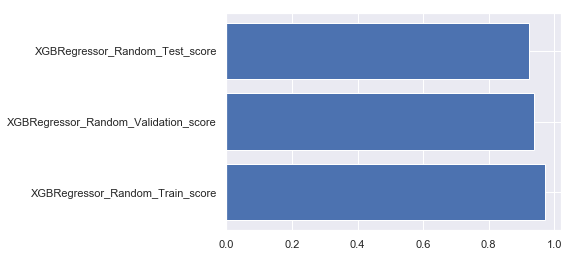

In [1145]:
#Passing random search's best params
pipe_xgbr_random = Pipeline([("scaler", scaler), ("xgbr", XGBRegressor(n_estimators=250, subsample= 0.7, min_child_weight= 4, max_depth= 3, learning_rate= 0.092, colsample_bytree= 0.9, random_state=random_st))])
pipe_xgbr_random.fit(X_train, y_train)
print("Train score: {:.2f}". format(pipe_xgbr_random.score(X_train, y_train)))
print("Validation score: {:.2f}". format(pipe_xgbr_random.score(X_val, y_val)))
print("Test score: {:.2f}". format(pipe_xgbr_random.score(X_test, y_test)))
plt.barh(['XGBRegressor_Random_Train_score', 'XGBRegressor_Random_Validation_score', 'XGBRegressor_Random_Test_score'],[pipe_xgbr_random.score(X_train, y_train), pipe_xgbr_random.score(X_val, y_val), pipe_xgbr_random.score(X_test, y_test)])
plt.show()

In [1146]:
b("==> From the above grid and random searches, it seems random search gives better results during validation however, there is no improvement in the performance on the test data across different parameter tuning techniques.\n==> Slightly, there is an overfit in the model. However, I choose Random Search parameters for XGB regressor as inputs.")

 *********************************************************************************************************************** 
 Observations: 
 *********************************************************************************************************************** 
 ==> From the above grid and random searches, it seems random search gives better results during validation however, there is no improvement in the performance on the test data across different parameter tuning techniques.
==> Slightly, there is an overfit in the model. However, I choose Random Search parameters for XGB regressor as inputs. 


### c. Model performance range at 95% confidence level

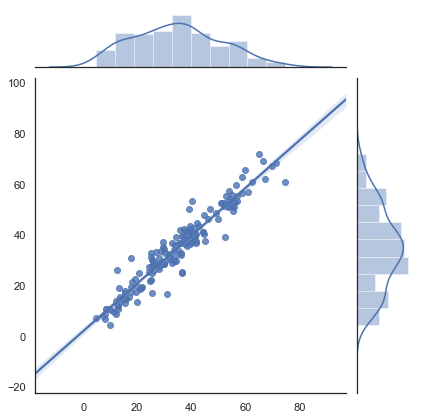

In [1147]:
#95% confidence level with 5% of error in the model
sns.set(style="darkgrid", color_codes=True)
y_pred = pipe_xgbr_random.predict(X_test)
with sns.axes_style("white"):
    sns.jointplot(x=y_test.strength.tolist(), y=y_pred.tolist(), kind="reg", color="b");

In [1150]:
f("==> After performing exhaustive EDA, feature engineering, model tweaking and cross validations, in my percespective, both LGBM and XGB regressors are performing well eventhough there is an overfitting slightly in both the regressors.\n\n==> As far as my analysis goes with model tuning and cross validations, I'd be pretty happy to go with both of these models. However, if I'm asked to choose one single productionizable regression engine, I'd go with XGB regressor as its model run duration is slightly better than LGBM regressor.\n\n==>Moreover, XGB and LGBM regressors would perform well for certain period (unless if there is any drastic drift in the data) as built-in regularizers applied in the models.\n\n==> These regressors are likely to perform with the prediction score range 88% to 98% at the confience level of 95%.")

 *********************************************************************************************************************** 
 Final Comments: 
 *********************************************************************************************************************** 
 ==> After performing exhaustive EDA, feature engineering, model tweaking and cross validations, in my percespective, both LGBM and XGB regressors are performing well eventhough there is an overfitting slightly in both the regressors.

==> As far as my analysis goes with model tuning and cross validations, I'd be pretty happy to go with both of these models. However, if I'm asked to choose one single productionizable regression engine, I'd go with XGB regressor as its model run duration is slightly better than LGBM regressor.

==>Moreover, XGB and LGBM regressors would perform well for certain period (unless if there is any drastic drift in the data) as built-in regularizers applied in the models.

==> These regressors are likel